# This is the detailed Analysis done on the KM data for fraud and anomaly detection project

In [111]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from scipy.stats import entropy

In [2]:
df = pd.read_excel('consolidated_Vishalquery_detail_data.xlsx')
#consolidated_Vishalquery_detail_data = df


Claims audit & fraud detection — feature summary
Bike - Claim-level Stats Validation

In [87]:
df.head(2)


,ClaimID,InvoiceDate,ClaimDate,ClaimItemId,ItemClaimedDate,ItemDescription,ItemQuantity,ClaimItemStatusDate,ClaimantName,ClaimantName.1,...,ProductName.1,ProductDescription,ProductManafacturer,SerialNumber,ClaimItemStatus,ClaimItemStatusReason,SalesTransactionID,SaleQuantity,SaleAmount,AuditComment
0,351322,2022-02-17 06:00:00,NaN,351322,2022-02-18 18:12:23.856,NaN,1,2022-02-18 18:27:11.282,Sheila Mundey,Sheila Mundey,...,BIZHUB 654E PRINTER COPIER,NaN,NaN,a5yn017008872,Cancelled,NaN,NaN,NaN,NaN,NaN
1,351472,2021-08-10 05:00:00,NaN,351472,2022-03-02 14:48:57.054,NaN,1,2022-03-02 14:48:57.054,Christian Colasono,Christian Colasono,...,BIZHUB C750I PRINTER COPIER,NaN,NaN,ACKN011001276,Processed,Select For Audit,386753.0,1.0,NaN,NaN


In [18]:
df.columns

Index(['ClaimID', 'InvoiceDate', 'ClaimDate', 'ClaimItemId', 'ItemClaimedDate',
       'ItemDescription', 'ItemQuantity', 'ClaimItemStatusDate',
       'ClaimantName', 'ClaimantName.1', 'ClaimName', 'ProductSoldDate',
       'ClaimSubmitionDate', 'DealerName', 'ProductID', 'ProductStatus',
       'ProductName', 'IsSerializedProduct', 'ProductName.1',
       'ProductDescription', 'ProductManafacturer', 'SerialNumber',
       'ClaimItemStatus', 'ClaimItemStatusReason', 'SalesTransactionID',
       'SaleQuantity', 'SaleAmount', 'AuditComment'],
      dtype='str')

In [66]:
len(df)

128805

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128805 entries, 0 to 128804
Data columns (total 28 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   ClaimID                128805 non-null  int64         
 1   InvoiceDate            127608 non-null  datetime64[us]
 2   ClaimDate              0 non-null       float64       
 3   ClaimItemId            128805 non-null  int64         
 4   ItemClaimedDate        125081 non-null  datetime64[us]
 5   ItemDescription        0 non-null       float64       
 6   ItemQuantity           128805 non-null  int64         
 7   ClaimItemStatusDate    128805 non-null  datetime64[us]
 8   ClaimantName           128805 non-null  str           
 9   ClaimantName.1         128805 non-null  str           
 10  ClaimName              128805 non-null  str           
 11  ProductSoldDate        127608 non-null  datetime64[us]
 12  ClaimSubmitionDate     125081 non-null  datetime64[us]


In [22]:
df.ProductStatus.value_counts()

ProductStatus
A    128634
I       171
Name: count, dtype: int64

In [23]:
df1 = df.ProductName.value_counts().reset_index().rename(columns={'index': 'ProductName', 'ProductName': 'count'})
df1

,count,count
0,BIZHUB C450I 45 PPM COLOR MFP,9067
1,BIZHUB C451I W DF-713 45 PPM MFP,8604
2,BIZHUB C301I W DF-714 30 PPM MFP,5853
3,BIZHUB C361I W DF-714 36 PPM MFP,4875
4,BIZHUB C251I W DF-714 25 PPM MFP,4803
...,...,...
730,ACCURIOPRESS C7090E TAA COMPLIANT,1
731,REMOTE INSTLLTN PER PRNT ENBLMNT PCK,1
732,KIP 7170 SYSTEM INSTALLATION KMBS,1
733,PWRFILTER W INRUSH PROTECT 120V 15A,1


In [24]:
df1.to_csv('/Users/lubina.zaidi/Documents/Claims audit and fraud detection/ProductName_count.csv', index=False)


Investigation of the product types sold by KM

 Product Family                      | Description                                              |
| ----------------------------------- | -------------------------------------------------------- |
| **Bizhub i-Series**                 | Office multifunction printers/copiers (largest category) |
| **AccurioPress**                    | Commercial production printing presses                   |
| **AccurioPrint**                    | High-volume production printers                          |
| **AccurioLabel**                    | Industrial label printing systems                        |
| **Kodak/Fujitsu Scanners**          | Document capture and imaging devices                     |
| **HP DesignJet/PageWide**           | Wide-format engineering and graphics printers            |
| **Fiery Controllers (IC Series)**   | Print server and workflow management systems             |
| **Finishers (FS Series)**           | Stapling/booklet finishing modules                       |
| **Paper Feed Units (PF/LU Series)** | Additional paper capacity accessories                    |
| **Document Feeders (DF Series)**    | Automatic document scanning feeders                      |
| **Fax Kits (FK Series)**            | Fax modules for MFPs                                     |


In [26]:
product_types_details = pd.read_excel('product_category_summary.xlsx')
product_types_details

,product_category_summary,Unnamed: 1,Unnamed: 2
0,Category,Units_Bought,Distinct_Product_Names
1,Bizhub office multifunction printers/copiers,105034,165
2,Bizhub A4 desktop/workgroup devices,16984,54
3,AccurioPress production presses,2230,49
4,Finishers and post-processing accessories,1269,73
5,AccurioPrint production printers,1137,7
6,"Paper-feed units, trays, cabinets and desks",1000,49
7,"Other accessories, rebates and miscellaneous i...",358,115
8,Fax kits,228,5
9,"Controllers, Fiery, licenses and interface kits",198,43


- Based on the product names in the file,

 0 out of 128,805 items appear to be tire-related, resulting in an estimated 0.00% tire-related product mix.

The file appears to be a Konica Minolta office equipment and print solutions product catalog, not an automotive or tire-industry catalog.

If your fraud analysis is focused on tire claims, then this product file likely represents the dealer equipment sold by Konica Minolta, not the actual products being claimed under warranty. In that case, we may need to analyze a different product field from the claims data.

Investigating the claim reasons and status 

In [68]:
df.ClaimItemStatusReason.value_counts()

ClaimItemStatusReason
Completed                                             112121
Rejected due to KMAP Sale                               2346
Select For Audit                                        1532
Passed System Validation & Audit not Required           1161
Rejected                                                 246
Recalled                                                 175
Other                                                    155
Duplicate Claim                                            9
Submitted                                                  7
No Match Found                                             2
unit's ineligible as it's replacement & was unsold         1
Approved by Auditor                                        1
Name: count, dtype: int64

Once a claim has passed System Validation it goes to the Audit Process- approved - completed sattus
Audit process - edit and fix problems - Returned
Audit process - rejected 

Rejected due to KMAP Sale - KM specfic type of sale - claims submitted were not eligible for sales, so they were rejected
Completed - once claim a
returned. - The system validates that the Product ID and Product Unique ID match and someone else has claimed it.
Pending - claim is submitted and is waiting for approval after all teh required documents are submitted and has passed intial validation checks.
Draft - Claims in Draft Status may be Canceled by the submitter or claimant.Claims in Pending System Validation or Returned status may be recalled to Draft Status if information needs to be updated in the claim.  

If product does not have a Product Unique ID (serial number, VIN) to validate, then the claim will pass system validation automatically. 

In [38]:
df.ClaimItemStatus.value_counts()

ClaimItemStatus
Processed    114736
Cancelled     10443
Rejected       2750
Draft           782
Approved         74
Returned          9
Pending           9
                  1
Audit             1
Name: count, dtype: int64

In [39]:
df.IsSerializedProduct.value_counts()

IsSerializedProduct
Y    126317
Name: count, dtype: int64

In [ ]:
128805 - 126317

2488

In [40]:
df_claimstautus_analysis = df.groupby(['ClaimItemStatus', 'ClaimItemStatusReason']).agg({
    'ClaimID': 'count'}).reset_index().rename(columns={'ClaimID': 'count'})

df_claimstautus_analysis 

,ClaimItemStatus,ClaimItemStatusReason,count
0,,Completed,1
1,Approved,Approved by Auditor,1
2,Approved,Passed System Validation & Audit not Required,73
3,Audit,Select For Audit,1
4,Cancelled,unit's ineligible as it's replacement & was un...,1
5,Draft,Recalled,175
6,Pending,No Match Found,2
7,Pending,Submitted,7
8,Processed,Completed,112117
9,Processed,Passed System Validation & Audit not Required,1088


In [67]:
df.DealerName.value_counts()

DealerName
PACIFIC OFFICE AUTOMATION, INC.    26584
PERRY PRO TECH, INC.                7661
ALL COPY PRODUCTS, LLC              7298
DBA NOVATECH-MEMPHIS                6083
EDWARDS BUSINESS MACHINES, INC.     4534
                                   ...  
COPITEX BUSINESS MACHINES              1
PROCOPY, INC.                          1
O/C BUSINESS SYSTEMS                   1
STEAMROLLER COPIES, INC.               1
Southeast Sls                          1
Name: count, Length: 224, dtype: int64

Dates conversion to YYYY-MM-DD. num of days is calculated from teh invoice date - the product was sold and itemclaim date , when the claim was filed.

In [3]:

# Format selected date columns as YYYY-MM-DD strings
date_cols_to_format = ['InvoiceDate', 'ItemClaimedDate', 'ClaimItemStatusDate']
# STEP 2: Convert dates
for col in date_cols_to_format:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce').dt.strftime('%Y-%m-%d')

print("\nSTEP 2: After converting dates")
print(df[['ClaimantName', 'InvoiceDate', 'ItemClaimedDate', 'ClaimSubmitionDate']].head())

# STEP 2: Calculate delay 

# compute days difference using temporary datetime conversion (safe if cols are strings)
invoicedate= pd.to_datetime(df['InvoiceDate'], errors='coerce')
itemclaimeddate = pd.to_datetime(df['ItemClaimedDate'], errors='coerce')
df['num_days'] = (itemclaimeddate - invoicedate).dt.days.round(0).astype("Int64")

#print("\nSTEP 3: Delay calculation")
#print(df[['ClaimantName', 'InvoiceDate', 'ItemClaimedDate', 'ClaimSubmitionDate', 'num_days']].head(3))



STEP 2: After converting dates
         ClaimantName InvoiceDate ItemClaimedDate      ClaimSubmitionDate
0       Sheila Mundey  2022-02-17      2022-02-18 2022-02-18 18:12:23.856
1  Christian Colasono  2021-08-10      2022-03-02 2022-03-02 14:48:57.054
2          Ryan Eades  2022-02-01      2022-02-24 2022-02-24 14:55:45.287
3          Admin User  2022-02-09      2022-02-16 2022-02-16 10:24:56.946
4       Sheila Mundey  2020-02-01      2022-02-16 2022-02-16 13:50:59.921


In [72]:
df.columns

Index(['ClaimID', 'InvoiceDate', 'ClaimDate', 'ClaimItemId', 'ItemClaimedDate',
       'ItemDescription', 'ItemQuantity', 'ClaimItemStatusDate',
       'ClaimantName', 'ClaimantName.1', 'ClaimName', 'ProductSoldDate',
       'ClaimSubmitionDate', 'DealerName', 'ProductID', 'ProductStatus',
       'ProductName', 'IsSerializedProduct', 'ProductName.1',
       'ProductDescription', 'ProductManafacturer', 'SerialNumber',
       'ClaimItemStatus', 'ClaimItemStatusReason', 'SalesTransactionID',
       'SaleQuantity', 'SaleAmount', 'AuditComment', 'num_days'],
      dtype='str')

In [5]:
df['num_days_buckets'] = pd.cut(df['num_days'], bins=[-1, 0, 7, 14, 21, 30, 60, 90, 180, float('inf')],
                              labels=['0 days', '1-week', '2-week', '3-week', '4-week', '30-60 days', '60-90 days', '90-180 days', '180+ days']) 

Developing the Fraud and Anamoly flags

In [ ]:

# fraud flag - if any of the below conditions are met, then flag as 1, else 0

pattern = r"Duplicate Claim|No Match Found|unit's ineligible as it's replacement & was unsold|Rejected"
df['fraud_flag'] = (
	df['ClaimItemStatusReason'].astype(str).str.contains(pattern, case=False, na=False)
	| df['ClaimItemStatus'].astype(str).str.contains(r"Rejected|Duplicate Claim|No Match Found", case=False, na=False)).astype(int)


 # Anomaly flag - if any of the below conditions are met, then flag as 1, else 0
# df['anamoly_flag'] = (
#     df['ClaimItemStatusReason'].astype(str).str.contains("Recalled", case=False, na=False)
#     | df['ClaimItemStatus'].astype(str).str.contains(r"Cancelled|Returned|Draft|Pending", case=False, na=False)
#     | df['num_days_buckets'].isin(['60-90 days', '90-180 days', '180+ days'])
# ).astype(int)

### updated anamoly_flag - Iteration 2 - removed ClaimItemStatus condition and added only 90+ days condition

df['anamoly_flag'] = (
     df['ClaimItemStatusReason'].astype(str).str.contains("Recalled", case=False, na=False)
     #| df['ClaimItemStatus'].astype(str).str.contains(r"Cancelled|Returned|Draft|Pending", case=False, na=False)
     | df['num_days_buckets'].isin(['90-180 days', '180+ days'])
).astype(int)



In [95]:
# ============================================================================
# PRODUCT VELOCITY FEATURE  (separate from anamoly_flag)
# ============================================================================
# WHAT IT MEASURES:
#   Existing product features measure QUANTITY PER CLAIM.
#   This measures CLAIMS PER MONTH - a surge in how often a product is
#   claimed, even when every individual quantity looks normal.
# ============================================================================

VELOCITY_MULTIPLIER = 2.0   # month exceeds 2x the product's own average
VELOCITY_MIN_MONTHS = 3     # need some history before judging

# --- claim_month (safe to recompute; behavioral cell rebuilds it anyway) ---
df['ItemClaimedDate'] = pd.to_datetime(df['ItemClaimedDate'], errors='coerce')
df['claim_month'] = (df['ItemClaimedDate'].dt.to_period('M')
                     .astype(str).replace('NaT', 'Unknown'))

# --- STEP 1: claims per product per month ---
_pm = (df.groupby(['ProductID', 'claim_month'])
         .agg(product_month_claims=('ClaimID', 'count'))
         .reset_index())

# --- STEP 2: each product's own monthly baseline ---
_pb = (_pm.groupby('ProductID')
          .agg(product_avg_month_claims=('product_month_claims', 'mean'),
               product_active_months=('claim_month', 'nunique'))
          .reset_index())

_pm = _pm.merge(_pb, on='ProductID', how='left')

# --- STEP 3: ratio of this month vs a normal month ---
_pm['product_velocity_ratio'] = (
    _pm['product_month_claims']
    / _pm['product_avg_month_claims'].replace(0, np.nan))

_pm['product_velocity_ratio'] = (_pm['product_velocity_ratio']
                                 .replace([np.inf, -np.inf], np.nan)
                                 .fillna(0))

# --- STEP 4: spike flag (guarded by minimum history) ---
_pm['product_velocity_spike_flag'] = (
    (_pm['product_velocity_ratio'] >= VELOCITY_MULTIPLIER)
    & (_pm['product_active_months'] >= VELOCITY_MIN_MONTHS)
).astype(int)

# --- STEP 5: merge back to claim level (suffix-proof, re-run safe) ---
_vel_cols = ['product_month_claims', 'product_avg_month_claims',
             'product_active_months', 'product_velocity_ratio',
             'product_velocity_spike_flag']

df = df.drop(columns=[c for c in _vel_cols if c in df.columns], errors='ignore')
df = df.merge(_pm[['ProductID', 'claim_month'] + _vel_cols],
              on=['ProductID', 'claim_month'], how='left')

df[_vel_cols] = df[_vel_cols].fillna(0)


# --- CHECK: is this feature worth keeping? ---
_base = df['fraud_flag'].mean()
_mask = df['product_velocity_spike_flag'] == 1
_n = int(_mask.sum())

print(f"Velocity spikes  : {_n:,} claims ({100*_n/len(df):.2f}%)")
if _n:
    _lift = df.loc[_mask, 'fraud_flag'].mean() / _base
    print(f"Lift vs fraud    : {_lift:.2f}x   (base rate {100*_base:.2f}%)")
    print("  >= 2.0x  -> strong, keep" if _lift >= 2.0
          else "  1.5-2.0x -> moderate, keep as model feature" if _lift >= 1.5
          else "  < 1.5x   -> weak; raise VELOCITY_MULTIPLIER or drop")


Velocity spikes  : 39,491 claims (30.66%)
Lift vs fraud    : 1.18x   (base rate 2.14%)
  < 1.5x   -> weak; raise VELOCITY_MULTIPLIER or drop


In [71]:
df.columns

Index(['ClaimID', 'InvoiceDate', 'ItemClaimedDate', 'ItemQuantity', 'ClaimantName', 'DealerName', 'ProductID', 'ProductStatus', 'ProductName',
       'IsSerializedProduct', 'ClaimItemStatus', 'ClaimItemStatusReason', 'num_days', 'num_days_buckets', 'fraud_flag', 'anamoly_flag',
       'quantity_ratio_to_product_avg', 'quantity_z_score', 'high_quantity_anomaly_flag', 'claimant_active_months', 'monthly_claim_count_z_score',
       'monthly_units_z_score', 'high_monthly_claim_activity_flag', 'low_monthly_claim_activity_flag', 'high_monthly_units_flag', 'claim_month',
       'product_volume_ratio', 'product_volume_spike_flag', 'product_month_claims', 'product_avg_month_claims', 'product_active_months',
       'product_velocity_ratio', 'product_velocity_spike_flag'],
      dtype='str')

In [73]:
df[['anamoly_flag','fraud_flag']].value_counts()

anamoly_flag  fraud_flag
0             0             118785
1             0               7258
0             1               2341
1             1                421
Name: count, dtype: int64

In [74]:
df[['anamoly_flag','fraud_flag']].sum()

anamoly_flag    7679
fraud_flag      2762
dtype: int64

In [11]:
print("\n Total of fraud and anomly flags :",7679 + 2762 )
print("\n The percentage of fraud and anomaly cases:", 10441/128805 * 100)



 Total of fraud and anomly flags : 10441

 The percentage of fraud and anomaly cases: 8.10605178370405


In [11]:
#df[['anamoly_flag','fraud_flag']].sum()

anamoly_flag    25806
fraud_flag       2762
dtype: int64

BEHAVIORAL FEATURE ENGINEERING FOR KM CLAIMS - ISOLATION FOREAST

In [75]:
# ============================================================================
# KM CLAIMS - BEHAVIORAL FEATURE ENGINEERING (SCALED-DOWN, FIXED)
# ============================================================================

import numpy as np
import pandas as pd


# ============================================================================
# HELPERS
# ============================================================================

def _anomaly_col(df):
    """Return whichever anomaly-flag column name exists ('anamoly_flag' typo ok)."""
    for c in ('anamoly_flag', 'anomaly_flag'):
        if c in df.columns:
            return c
    raise KeyError(
        "Dataframe must contain 'anamoly_flag' or 'anomaly_flag'. "
        f"Found columns: {list(df.columns)[:25]} ..."
    )


def _present(df, cols):
    """Keep only the columns that actually exist -> safe display / selection."""
    return [c for c in cols if c in df.columns]


# Master list of columns this pipeline MAY generate. Used only for cleanup,
# and every use is guarded by 'if c in df.columns', so commenting out a # feature above will never cause a KeyError here.
_GENERATED_COLS = [
    'product_claim_count', 'product_total_units', 'product_avg_units',
    'product_median_units', 'product_std_units', 'product_min_units',
    'product_max_units', 'quantity_vs_product_avg',
    'quantity_ratio_to_product_avg', 'quantity_z_score',
    'high_quantity_anomaly_flag', 'low_quantity_anomaly_flag',
    'monthly_claim_count', 'monthly_units_claimed',
    'monthly_unique_dealers', 'monthly_unique_products',
    'claimant_avg_monthly_claims', 'claimant_std_monthly_claims',
    'claimant_median_monthly_claims', 'claimant_avg_monthly_units',
    'claimant_std_monthly_units', 'claimant_active_months',
    'monthly_claim_count_z_score', 'monthly_units_z_score',
    'high_monthly_claim_activity_flag', 'low_monthly_claim_activity_flag',
    'high_monthly_units_flag', 'claim_month',
]


# ============================================================================
# 1. PREPARE DATA
# ============================================================================

def prepare_behavioral_data(df):
    """Clean copy, re-run safe, numeric quantity, datetime date, claim_month."""
    work = df.copy()

    # Re-run safety: drop duplicate names + leftover generated columns
    work = work.loc[:, ~work.columns.duplicated()]
    work = work.drop(
        columns=[c for c in _GENERATED_COLS if c in work.columns],
        errors='ignore')

    work['ItemQuantity'] = pd.to_numeric(work['ItemQuantity'], errors='coerce').fillna(0)

    work['ItemClaimedDate'] = pd.to_datetime(work['ItemClaimedDate'], errors='coerce')

    work['claim_month'] = work['ItemClaimedDate'].dt.to_period('M').astype(str)
    work['claim_month'] = work['claim_month'].replace('NaT', 'Unknown')

    return work


# ============================================================================
# 2. PRODUCT-LEVEL QUANTITY BASELINE 
# ============================================================================

def build_product_quantity_baseline(df, product_col='ProductID'):
    """Typical quantity profile per product."""
    product_baseline = (
        df.groupby(product_col)
        .agg(
            product_claim_count=('ClaimID', 'count'),
            product_total_units=('ItemQuantity', 'sum'),
            product_avg_units=('ItemQuantity', 'mean'),
            # product_median_units=('ItemQuantity', 'median'),
            product_std_units=('ItemQuantity', 'std'),
            # product_min_units=('ItemQuantity', 'min'),
            # product_max_units=('ItemQuantity', 'max'),
        )
        .reset_index()
    )
  
    product_baseline['product_std_units'] = (product_baseline['product_std_units'].fillna(0))

    return product_baseline


# ============================================================================
# 3. PRODUCT QUANTITY ANOMALY FEATURES (per claim)
# ============================================================================

def add_product_quantity_features(df, product_col='ProductID'):
    """Compare each claim's quantity to the product's typical quantity."""
    work = df.copy()

    # Take my claims data, calculate the typical quantity for each product, and save that summary table as product_baseline.
    product_baseline = build_product_quantity_baseline(work, product_col=product_col)

    # Suffix-proof merge
    dup = [c for c in product_baseline.columns if c != product_col and c in work.columns]

    work = work.drop(columns=dup, errors='ignore')

    work = work.merge(product_baseline, on=product_col, how='left')

    work['quantity_vs_product_avg'] = (work['ItemQuantity'] - work['product_avg_units'])

    work['quantity_ratio_to_product_avg'] = (work['ItemQuantity'] / work['product_avg_units'].replace(0, np.nan))

    # FIX 3: this cleanup was commented out. It is REQUIRED -- without it # inf / NaN survive and break RobustScaler + IsolationForest later.
    
    work['quantity_ratio_to_product_avg'] = (work['quantity_ratio_to_product_avg'].replace([np.inf, -np.inf], np.nan).fillna(0))

    # z = (claim qty - product avg) / product std
    work['quantity_z_score'] = (
        (work['ItemQuantity'] - work['product_avg_units'])/ work['product_std_units'].replace(0, np.nan))
    
    work['quantity_z_score'] = (
        work['quantity_z_score'].replace([np.inf, -np.inf], np.nan).fillna(0))
    

    work['high_quantity_anomaly_flag'] = (work['quantity_z_score'] >= 3).astype(int)
    # work['low_quantity_anomaly_flag'] = (work['quantity_z_score'] <= -3).astype(int)

    return work, product_baseline


# ============================================================================
# 4. CLAIMANT MONTHLY ACTIVITY BASELINE
# ============================================================================

def build_claimant_monthly_baseline(df):
    """Claimant-month level activity table."""
    acol = _anomaly_col(df)

    claimant_monthly = (
        df.groupby(['ClaimantName', 'claim_month'])
        .agg(
            monthly_claim_count=('ClaimID', 'count'),
            monthly_units_claimed=('ItemQuantity', 'sum'),
            monthly_unique_dealers=('DealerName', 'nunique'),
            monthly_unique_products=('ProductID', 'nunique'),
            monthly_fraud_count=('fraud_flag', 'sum'),
            monthly_anomaly_count=(acol, 'sum'),
        )
        .reset_index()
    )

    return claimant_monthly


# ============================================================================
# 5. CLAIMANT MONTHLY ANOMALY FEATURES
# ============================================================================

def add_claimant_monthly_features(df):
    """Compare each claimant's month to their OWN typical monthly behavior."""
    work = df.copy()

    claimant_monthly = build_claimant_monthly_baseline(work)

    claimant_baseline = (
        claimant_monthly.groupby('ClaimantName')
        .agg(
            claimant_avg_monthly_claims=('monthly_claim_count', 'mean'),
            claimant_std_monthly_claims=('monthly_claim_count', 'std'),
            # claimant_median_monthly_claims=('monthly_claim_count', 'median'),
            claimant_avg_monthly_units=('monthly_units_claimed', 'mean'),
            claimant_std_monthly_units=('monthly_units_claimed', 'std'),
            claimant_active_months=('claim_month', 'nunique'),
        )
        .reset_index()
        .fillna(0)
    )

    claimant_monthly = claimant_monthly.merge(claimant_baseline, on='ClaimantName', how='left')

    # Monthly claim-count z-score
    claimant_monthly['monthly_claim_count_z_score'] = ( (claimant_monthly['monthly_claim_count']
         - claimant_monthly['claimant_avg_monthly_claims'])
        / claimant_monthly['claimant_std_monthly_claims'].replace(0, np.nan))

    
    claimant_monthly['monthly_claim_count_z_score'] = (claimant_monthly['monthly_claim_count_z_score'].replace([np.inf, -np.inf], np.nan).fillna(0))

    # Monthly units z-score
    claimant_monthly['monthly_units_z_score'] = ((claimant_monthly['monthly_units_claimed']- claimant_monthly['claimant_avg_monthly_units'])
        / claimant_monthly['claimant_std_monthly_units'].replace(0, np.nan))

    claimant_monthly['monthly_units_z_score'] = (claimant_monthly['monthly_units_z_score'].replace([np.inf, -np.inf], np.nan).fillna(0))

    # Threshold 2 (not 3): each claimant has few months, so std is noisy

    claimant_monthly['high_monthly_claim_activity_flag'] = (claimant_monthly['monthly_claim_count_z_score'] >= 2).astype(int)
    
    claimant_monthly['low_monthly_claim_activity_flag'] = (claimant_monthly['monthly_claim_count_z_score'] <= -2).astype(int)
    
    claimant_monthly['high_monthly_units_flag'] = (claimant_monthly['monthly_units_z_score'] >= 2).astype(int)
   
    monthly_cols = [c for c in claimant_monthly.columns if c not in ('ClaimantName', 'claim_month')]
    work = work.drop(
        columns=[c for c in monthly_cols if c in work.columns],
        errors='ignore'
    )

    work = work.merge(
        claimant_monthly[['ClaimantName', 'claim_month'] + monthly_cols],
        on=['ClaimantName', 'claim_month'],
        how='left'
    )

    return work, claimant_monthly, claimant_baseline


# ============================================================================
# 6. RUN FULL BEHAVIORAL FEATURE PIPELINE  
# ============================================================================

def run_behavioral_feature_pipeline(df):
    """Returns ONE claim-level dataframe with all behavioral features."""
    work = prepare_behavioral_data(df)
    work, product_baseline = add_product_quantity_features(work, product_col='ProductID')
    work, claimant_monthly, claimant_baseline = add_claimant_monthly_features(work)
    return work


# ============================================================================
# 7. EXECUTE
# ============================================================================

claims_behavioral = run_behavioral_feature_pipeline(df)

print("Rows:", len(claims_behavioral))
print("High-quantity anomalies:",
      int(claims_behavioral['high_quantity_anomaly_flag'].sum()))
print("High monthly-activity flags:",
      int(claims_behavioral['high_monthly_claim_activity_flag'].sum()))


# ============================================================================
# OUTPUT 1 - CLAIMS WITH UNUSUALLY HIGH PRODUCT QUANTITY
# ============================================================================

print("\n" + "=" * 80)
print("CLAIMS WITH UNUSUALLY HIGH PRODUCT QUANTITY")
print("=" * 80)

_high_qty = claims_behavioral[claims_behavioral['high_quantity_anomaly_flag'] == 1]

if len(_high_qty) == 0:
    print("No claims exceeded the z >= 3 quantity threshold. "
          "(Normal if quantities are tightly clustered; "
          "lower the threshold to 2 or 2.5 to see more.)")
else:
    # FIX 2: _present() drops any column you commented out
    # (e.g. product_median_units) so the display never KeyErrors.
    _cols1 = _present(_high_qty, [
        'ClaimID', 'ClaimantName', 'DealerName', 'ProductID', 'ProductName',
        'ItemQuantity', 'product_avg_units', 'product_median_units',
        'product_std_units', 'quantity_z_score',
        'quantity_ratio_to_product_avg', 'high_quantity_anomaly_flag',
    ])
    display(
        _high_qty[_cols1]
        .sort_values('quantity_z_score', ascending=False)
        .head(20)
    )


# ============================================================================
# OUTPUT 2 - FINAL CLAIM-LEVEL BEHAVIORAL FEATURES
# ============================================================================

print("\n" + "=" * 80)
print("FINAL CLAIM-LEVEL BEHAVIORAL FEATURES")
print("=" * 80)

_cols2 = _present(claims_behavioral, [
    'ClaimID', 'ClaimantName', 'DealerName', 'ProductID', 'ProductName',
    'ItemQuantity', 'claim_month', 'quantity_z_score',
    'quantity_ratio_to_product_avg', 'high_quantity_anomaly_flag',
    'monthly_claim_count', 'claimant_avg_monthly_claims',
    'monthly_claim_count_z_score', 'high_monthly_claim_activity_flag',
    'monthly_units_claimed', 'monthly_units_z_score', 'high_monthly_units_flag',
])

display(claims_behavioral[_cols2].head(20))





Rows: 128805
High-quantity anomalies: 54
High monthly-activity flags: 29218

CLAIMS WITH UNUSUALLY HIGH PRODUCT QUANTITY


,ClaimID,ClaimantName,DealerName,ProductID,ProductName,ItemQuantity,product_avg_units,product_std_units,quantity_z_score,quantity_ratio_to_product_avg,high_quantity_anomaly_flag
4425,442437,Brode Albrecht,"JAMES IMAGING SYSTEMS, INC.",AA2M013,BIZHUB C250I WITH DF-714,2,1.000318,0.017843,56.026782,1.999363,1
5909,489488,Joe Lardiere,DBA ATLANTIC TOMORROWS OFFICE,AC76017,BIZHUB 450I 45 PPM MONOCHROME MFP,2,1.000534,0.023113,43.243503,1.998932,1
7777,512189,John Hartman,DBA NOVATECH-MEMPHIS,AA7N017,BIZHUB C650I 65 PPM MFP,2,1.000558,0.023616,42.320215,1.998885,1
7415,517049,Tyler Hogan,"PACIFIC OFFICE AUTOMATION, INC.",ACKN017,BIZHUB C750I 75 PPM MFP,3,1.001563,0.055902,35.749131,2.995318,1
7416,517049,Tyler Hogan,"PACIFIC OFFICE AUTOMATION, INC.",ACKN017,BIZHUB C750I 75 PPM MFP,3,1.001563,0.055902,35.749131,2.995318,1
8655,520593,Kristy Becker,"PACIFIC OFFICE AUTOMATION, INC.",AC74017,BIZHUB 650I 65 PPM MONOCHROME MFP,2,1.001168,0.034179,29.223298,1.997666,1
33235,1045971,Edward Stamm,"PACIFIC OFFICE AUTOMATION, INC.",135700,DK-516 COPY DESK,5,1.076923,0.412429,9.512132,4.642857,1
53278,1231543,Doug Sanner,"FORD BUSINESS MACHINES, INC.",A883012,FK-514 FAX KIT 1ST 2ND LINE,51,1.836257,5.186756,9.478707,27.773885,1
40414,1114088,Doug Sanner,"FORD BUSINESS MACHINES, INC.",AC28W11,PK-524 2 3 PUNCH UNIT FOR FS-539,18,1.347368,1.773135,9.391630,13.359375,1
116163,2097187,Lizzy Brown,"PLUS, INC.",ADXK012,C301I CLR COPIER PRINTER WITH DF-714 TAA,7,1.181102,0.683331,8.515486,5.926667,1



FINAL CLAIM-LEVEL BEHAVIORAL FEATURES


,ClaimID,ClaimantName,DealerName,ProductID,ProductName,ItemQuantity,claim_month,quantity_z_score,quantity_ratio_to_product_avg,high_quantity_anomaly_flag,monthly_claim_count,claimant_avg_monthly_claims,monthly_claim_count_z_score,high_monthly_claim_activity_flag,monthly_units_claimed,monthly_units_z_score,high_monthly_units_flag
0,351322,Sheila Mundey,Field Employees - BUS,A5YN017,BIZHUB 654E PRINTER COPIER,1,2022-02,0.000000,1.000000,0,12.0,6.500000,0.707107,0.0,12.0,0.707107,0.0
1,351472,Christian Colasono,DBA FUNCTION4,ACKN011,BIZHUB C750I PRINTER COPIER,1,2022-03,0.000000,1.000000,0,8.0,11.923077,-0.245475,0.0,8.0,-0.245475,0.0
2,351483,Ryan Eades,"PACIFIC OFFICE AUTOMATION, INC.",AC57011,ACCURIOPRESS C4080,1,2022-02,0.000000,1.000000,0,1.0,3.333333,-0.666214,0.0,1.0,-0.666214,0.0
3,351182,Admin User,National,AAC2011,ACCURIOPRESS C3080P,1,2022-02,0.000000,1.000000,0,1.0,1.000000,0.000000,0.0,1.0,0.000000,0.0
4,351187,Sheila Mundey,National,11105,MGI JV3D EVO CORONA TREATMENT MODULE,1,2022-02,0.000000,1.000000,0,12.0,6.500000,0.707107,0.0,12.0,0.707107,0.0
5,351314,Sheila Mundey,Field Employees - BUS,PLS401F,PLS-401F LABEL FINISHER,1,2022-02,0.000000,1.000000,0,12.0,6.500000,0.707107,0.0,12.0,0.707107,0.0
6,351389,Admin User,National,08ASD101A1M0,AS FOUNDATIONS DEVICE 1-9,1,NaN,0.000000,1.000000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,351467,Garet Gordon,DBA NOVATECH-MEMPHIS,AA2M013,BIZHUB C250I WITH DF-714,1,2022-02,-0.017843,0.999682,0,65.0,20.628571,1.577896,0.0,65.0,1.577896,0.0
8,351467,Garet Gordon,DBA NOVATECH-MEMPHIS,AA7R011,BIZHUB C450I 45 PPM COLOR MFP,1,2022-02,0.000000,1.000000,0,65.0,20.628571,1.577896,0.0,65.0,1.577896,0.0
9,351467,Garet Gordon,DBA NOVATECH-MEMPHIS,AA7R011,BIZHUB C450I 45 PPM COLOR MFP,1,2022-02,0.000000,1.000000,0,65.0,20.628571,1.577896,0.0,65.0,1.577896,0.0


In [76]:
claims_behavioral.columns

Index(['ClaimID', 'InvoiceDate', 'ItemClaimedDate', 'ItemQuantity', 'ClaimantName', 'DealerName', 'ProductID', 'ProductStatus', 'ProductName',
       'IsSerializedProduct', 'ClaimItemStatus', 'ClaimItemStatusReason', 'num_days', 'num_days_buckets', 'fraud_flag', 'anamoly_flag', 'product_volume_ratio',
       'product_volume_spike_flag', 'product_month_claims', 'product_avg_month_claims', 'product_active_months', 'product_velocity_ratio',
       'product_velocity_spike_flag', 'claim_month', 'product_claim_count', 'product_total_units', 'product_avg_units', 'product_std_units',
       'quantity_vs_product_avg', 'quantity_ratio_to_product_avg', 'quantity_z_score', 'high_quantity_anomaly_flag', 'monthly_claim_count',
       'monthly_units_claimed', 'monthly_unique_dealers', 'monthly_unique_products', 'monthly_fraud_count', 'monthly_anomaly_count',
       'claimant_avg_monthly_claims', 'claimant_std_monthly_claims', 'claimant_avg_monthly_units', 'claimant_std_monthly_units', 'claimant_activ

In [33]:
claims_behavioral.to_csv('claims_behavioral.csv')

In [77]:
# 
cols_to_drop = [
    'ClaimDate','ClaimItemStatusDate','ClaimItemId','ItemDescription','ProductName.1',
       'ProductDescription', 'ProductManafacturer', 'SerialNumber', 'SalesTransactionID',
       'SaleQuantity', 'SaleAmount', 'AuditComment','claim_month','ProductSoldDate','ClaimSubmitionDate',
       'product_claim_count', 'product_total_units', 'product_avg_units',
       'product_std_units', 'quantity_vs_product_avg','monthly_claim_count',
       'monthly_units_claimed', 'monthly_unique_dealers',
       'monthly_unique_products', 'monthly_fraud_count',
       'monthly_anomaly_count', 'claimant_avg_monthly_claims',
       'claimant_std_monthly_claims', 'claimant_avg_monthly_units',
       'claimant_std_monthly_units','ClaimantName.1','ClaimName'
]
cols = [c for c in cols_to_drop if c in claims_behavioral.columns]
df = claims_behavioral.drop(columns=cols)

In [19]:
df.head(3)

,ClaimID,InvoiceDate,ItemClaimedDate,ItemQuantity,ClaimantName,DealerName,ProductID,ProductStatus,ProductName,IsSerializedProduct,...,anamoly_flag,quantity_ratio_to_product_avg,quantity_z_score,high_quantity_anomaly_flag,claimant_active_months,monthly_claim_count_z_score,monthly_units_z_score,high_monthly_claim_activity_flag,low_monthly_claim_activity_flag,high_monthly_units_flag
0,351322,2022-02-17,2022-02-18,1,Sheila Mundey,Field Employees - BUS,A5YN017,A,BIZHUB 654E PRINTER COPIER,Y,...,0,1.0,0.0,0,2.0,0.707107,0.707107,0.0,0.0,0.0
1,351472,2021-08-10,2022-03-02,1,Christian Colasono,DBA FUNCTION4,ACKN011,A,BIZHUB C750I PRINTER COPIER,Y,...,1,1.0,0.0,0,13.0,-0.245475,-0.245475,0.0,0.0,0.0
2,351483,2022-02-01,2022-02-24,1,Ryan Eades,"PACIFIC OFFICE AUTOMATION, INC.",AC57011,A,ACCURIOPRESS C4080,Y,...,0,1.0,0.0,0,6.0,-0.666214,-0.666214,0.0,0.0,0.0


In [78]:
cols_to_round = [
    'monthly_claim_count_z_score',
    'monthly_units_z_score']

df[cols_to_round] = (
    df[cols_to_round].round(2)
)

In [13]:
df.head(3)

,ClaimID,InvoiceDate,ClaimDate,ClaimItemId,ItemClaimedDate,ItemDescription,ItemQuantity,ClaimItemStatusDate,ClaimantName,ClaimantName.1,...,ClaimItemStatus,ClaimItemStatusReason,SalesTransactionID,SaleQuantity,SaleAmount,AuditComment,num_days,num_days_buckets,fraud_flag,anamoly_flag
0,351322,2022-02-17,NaN,351322,2022-02-18,NaN,1,2022-02-18,Sheila Mundey,Sheila Mundey,...,Cancelled,NaN,NaN,NaN,NaN,NaN,1,1-week,0,0
1,351472,2021-08-10,NaN,351472,2022-03-02,NaN,1,2022-03-02,Christian Colasono,Christian Colasono,...,Processed,Select For Audit,386753.0,1.0,NaN,NaN,204,180+ days,0,1
2,351483,2022-02-01,NaN,351483,2022-02-24,NaN,1,2022-02-24,Ryan Eades,Ryan Eades,...,Processed,Select For Audit,351719.0,1.0,NaN,NaN,23,4-week,0,0


In [21]:
df.columns

Index(['ClaimID', 'InvoiceDate', 'ItemClaimedDate', 'ItemQuantity',
       'ClaimantName', 'DealerName', 'ProductID', 'ProductStatus',
       'ProductName', 'IsSerializedProduct', 'ClaimItemStatus',
       'ClaimItemStatusReason', 'num_days', 'num_days_buckets', 'fraud_flag',
       'anamoly_flag', 'quantity_ratio_to_product_avg', 'quantity_z_score',
       'high_quantity_anomaly_flag', 'claimant_active_months',
       'monthly_claim_count_z_score', 'monthly_units_z_score',
       'high_monthly_claim_activity_flag', 'low_monthly_claim_activity_flag',
       'high_monthly_units_flag'],
      dtype='str')

Steamlined Isolation forest algorithm : Isolation Forest is one of the best starting algorithms because it quickly surfaces unusual claimant and dealer behavior without requiring labeled fraud data

FINAL CODE - ISOLATION FOREST ALGORITHM FOR ANALOMY DETECTION FOR CLAIMANTS AND DEALERS

In [102]:
# ============================================================================
# KM CLAIMS AUDIT & FRAUD DETECTION - MASTER CONSOLIDATED PIPELINE
# ============================================================================
#
#   PART A - (SKIPPED) behavioral features already exist in df
#   PART B - Claimant & Dealer aggregation (with existing behavioral flags)
#   PART C - Isolation Forest anomaly scoring
#   PART D - Revised business-aware risk levels
#   PART E - Round all float outputs to 2 decimals + display results
#   PART F - Contamination diagnostic

#   2. Added claimant_active_months + the existing z-scores as features.
# ============================================================================

from unittest import result

import numpy as np
import pandas as pd

from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest

# ============================================================================
# PRODUCT VELOCITY FEATURE 
# ============================================================================
# WHAT IT MEASURES (genuinely new):
# Existing product features measure QUANTITY PER CLAIM.
# This measures CLAIMS PER MONTH - a surge in how often a product is
# claimed, even when every individual quantity looks normal.

def _velocity_aggs(df):
    """Return velocity agg specs only if the columns exist (safe if not run yet)."""
    specs = {}
    if 'product_velocity_spike_flag' in df.columns:
        specs['velocity_spike_count'] = ('product_velocity_spike_flag', 'sum')
        specs['velocity_spike_rate']  = ('product_velocity_spike_flag', 'mean')
    if 'product_velocity_ratio' in df.columns:
        specs['max_product_velocity_ratio'] = ('product_velocity_ratio', 'max')
        specs['avg_product_velocity_ratio'] = ('product_velocity_ratio', 'mean')
    return specs

#This means the pipeline still runs if you haven't executed the velocity cell yet — no KeyError.

# ============================================================================
# PART A - PASSTHROUGH (features already engineered upstream)
# ============================================================================

def run_behavioral_feature_pipeline(df):
    """df already has the behavioral features -- just clean types."""
    work = df.loc[:, ~df.columns.duplicated()].copy()

    work['ItemQuantity'] = pd.to_numeric(work['ItemQuantity'], errors='coerce').fillna(0)
    work['num_days'] = pd.to_numeric(work['num_days'], errors='coerce').astype(float)
    work['ItemClaimedDate'] = pd.to_datetime(work['ItemClaimedDate'], errors='coerce')

    return work


# ============================================================================
# PART B - CLAIMANT & DEALER FEATURES (using existing behavioral flags)
# ============================================================================

def build_claimant_features(df):
    """Aggregate claim-level behavioral flags to the claimant level."""
    claimant_features = (
        df.groupby('ClaimantName')
        .agg(
            total_claims=('ClaimID', 'count'),
            num_dealers=('DealerName', 'nunique'),
            num_products=('ProductID', 'nunique'),

            fraud_flag_count=('fraud_flag', 'sum'),
            fraud_flag_rate=('fraud_flag', 'mean'),
            anomaly_flag_count=('anamoly_flag', 'sum'),
            anomaly_flag_rate=('anamoly_flag', 'mean'),

            high_quantity_anomaly_flag_count=('high_quantity_anomaly_flag', 'sum'),
            high_quantity_anomaly_flag_rate=('high_quantity_anomaly_flag', 'mean'),

            high_monthly_claim_activity_flag_count=('high_monthly_claim_activity_flag', 'sum'),
            high_monthly_claim_activity_flag_rate=('high_monthly_claim_activity_flag', 'mean'),
            low_monthly_claim_activity_flag_count=('low_monthly_claim_activity_flag', 'sum'),
            low_monthly_claim_activity_flag_rate=('low_monthly_claim_activity_flag', 'mean'),

            high_monthly_units_flag_count=('high_monthly_units_flag', 'sum'),
            high_monthly_units_flag_rate=('high_monthly_units_flag', 'mean'),

            max_quantity_z_score=('quantity_z_score', 'max'),
            avg_quantity_z_score=('quantity_z_score', 'mean'),
            max_monthly_claim_count_z_score=('monthly_claim_count_z_score', 'max'),
            max_monthly_units_z_score=('monthly_units_z_score', 'max'),
            claimant_active_months=('claimant_active_months', 'max'),

            claims_over_90days=('num_days', lambda x: (x >= 90).sum()),
            avg_days_to_claim=('num_days', 'mean'),
        )
        .reset_index()
    )
    #aggs.update(_velocity_aggs(df))
    aggs = _velocity_aggs(df)
    
    
    claimant_features['claims_over_90days_rate'] = (
        claimant_features['claims_over_90days'] / claimant_features['total_claims']
    )
    claimant_features['products_per_claim'] = (
        claimant_features['num_products'] / claimant_features['total_claims']
    )
    claimant_features['dealers_per_claim'] = (
        claimant_features['num_dealers'] / claimant_features['total_claims']
    )

    return claimant_features.fillna(0)

def build_dealer_features(df):
    """Aggregate claim-level behavioral flags to the dealer level."""

    aggs = {
        'total_claims': ('ClaimID', 'count'),
        'num_claimants': ('ClaimantName', 'nunique'),
        'num_products': ('ProductID', 'nunique'),

        'fraud_flag_count': ('fraud_flag', 'sum'),
        'fraud_flag_rate': ('fraud_flag', 'mean'),
        'anomaly_flag_count': ('anamoly_flag', 'sum'),
        'anomaly_flag_rate': ('anamoly_flag', 'mean'),

        'high_quantity_anomaly_flag_count': ('high_quantity_anomaly_flag', 'sum'),
        'high_quantity_anomaly_flag_rate': ('high_quantity_anomaly_flag', 'mean'),

        'high_monthly_claim_activity_flag_count': ('high_monthly_claim_activity_flag', 'sum'),
        'high_monthly_claim_activity_flag_rate': ('high_monthly_claim_activity_flag', 'mean'),
        'low_monthly_claim_activity_flag_count': ('low_monthly_claim_activity_flag', 'sum'),
        'low_monthly_claim_activity_flag_rate': ('low_monthly_claim_activity_flag', 'mean'),

        'high_monthly_units_flag_count': ('high_monthly_units_flag', 'sum'),
        'high_monthly_units_flag_rate': ('high_monthly_units_flag', 'mean'),

        'max_quantity_z_score': ('quantity_z_score', 'max'),
        'avg_quantity_z_score': ('quantity_z_score', 'mean'),
        'max_monthly_claim_count_z_score': ('monthly_claim_count_z_score', 'max'),
        'max_monthly_units_z_score': ('monthly_units_z_score', 'max'),

        'claims_over_90days': ('num_days', lambda x: (x >= 90).sum()),
        'avg_days_to_claim': ('num_days', 'mean'),
    }

    aggs.update(_velocity_aggs(df))

    dealer_features = df.groupby('DealerName').agg(**aggs).reset_index()

    dealer_features['claims_over_90days_rate'] = (
        dealer_features['claims_over_90days'] / dealer_features['total_claims'])
    
    dealer_features['claimants_per_claim'] = (
        dealer_features['num_claimants'] / dealer_features['total_claims'])
    
    dealer_features['products_per_claim'] = (
        dealer_features['num_products'] / dealer_features['total_claims'])
    return dealer_features.fillna(0)

# ============================================================================
# PART C - ISOLATION FOREST SCORING
# ============================================================================

def score_anomalies(features_df, contamination=0.05):
    """
    Isolation Forest scoring.
    Adds: model_anomaly_flag, fraud_risk_score (0-100), model_risk_level.
    """
    result = features_df.copy()

    feature_cols = result.select_dtypes(include=np.number).columns.tolist()

    X = (result[feature_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0))

    # FIX C: force plain float64 (removes nullable Int64 / pd.NA)

    X = X.astype('float64')

    # FIX C: drop constant (zero-variance) columns before scaling
    non_constant_cols = X.columns[X.nunique() > 1].tolist()
    if len(non_constant_cols) == 0:
        non_constant_cols = feature_cols
    X = X[non_constant_cols]

    # Scale
    X_scaled = RobustScaler().fit_transform(X)

    # FIX C: clean any residual NaN / inf after scaling
    X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)

    model = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        random_state=42,
    )
    model.fit(X_scaled)

    result['model_anomaly_flag'] = (model.predict(X_scaled) == -1).astype(int)

    raw_score = -model.score_samples(X_scaled)
    result['fraud_risk_score'] = (
        MinMaxScaler(feature_range=(0, 100))
        .fit_transform(raw_score.reshape(-1, 1))
        .flatten()
    )
    result['fraud_risk_score'] = result['fraud_risk_score'].fillna(0).clip(0, 100)

    result['model_risk_level'] = pd.cut(
        result['fraud_risk_score'],
        bins=[-np.inf, 60, 80, np.inf],
        labels=['Low', 'Medium', 'High'],
    )

    return result


# ============================================================================
# PART D - REVISED BUSINESS-AWARE RISK LEVELS
# ============================================================================

def assign_revised_risk_level(df, entity_type='claimant'):
    """Combine IF score/flag with business behavior flags to set risk level."""
    result = df.copy()

    if entity_type == 'claimant':
        score_col = 'fraud_risk_score_claimant'
        anomaly_col = 'claimant_anomaly_flag'
        revised_col = 'claimant_risk_level'
        model_col = 'claimant_model_risk_level'
    elif entity_type == 'dealer':
        score_col = 'fraud_risk_score_dealer'
        anomaly_col = 'dealer_anomaly_flag'
        revised_col = 'dealer_risk_level'
        model_col = 'dealer_model_risk_level'
    else:
        raise ValueError("entity_type must be 'claimant' or 'dealer'")

    result[model_col] = pd.cut(
        result[score_col],
        bins=[-np.inf, 60, 80, np.inf],
        labels=['Low', 'Medium', 'High'],
    )

    behavior_count_cols = [
        'fraud_flag_count', 'anomaly_flag_count',
        'high_quantity_anomaly_flag_count',
        'high_monthly_claim_activity_flag_count',
        'low_monthly_claim_activity_flag_count',
        'high_monthly_units_flag_count', 'claims_over_90days',
    ]
    behavior_rate_cols = [
        'fraud_flag_rate', 'anomaly_flag_rate',
        'high_quantity_anomaly_flag_rate',
        'high_monthly_claim_activity_flag_rate',
        'low_monthly_claim_activity_flag_rate',
        'high_monthly_units_flag_rate', 'claims_over_90days_rate',
    ]
    behavior_count_cols = [c for c in behavior_count_cols if c in result.columns]
    behavior_rate_cols = [c for c in behavior_rate_cols if c in result.columns]

    # instead of: any flag at all.So:
    # has_high_rate = 1 means "this entity's worst behavioral rate is ≥ 50%"
    # has_mod_rate = 1 means "this entity's worst behavioral rate is ≥ 25%"

    has_high_rate = (result[behavior_rate_cols].max(axis=1) >= 0.50).astype(int)
    has_mod_rate  = (result[behavior_rate_cols].max(axis=1) >= 0.25).astype(int)


    high_condition = (
        (result[score_col] >= 80)# given by model
        | (result[anomaly_col] == 1)# given by model
        | (result.get('high_monthly_claim_activity_flag_count', 0) > 2)# we evolves it so it is business rule 
        | (result.get('high_monthly_units_flag_count', 0) > 2)# we evolves it so it is business rule
        | (result.get('high_quantity_anomaly_flag_count', 0) > 2)# we evolves it so it is business rule
        | (has_high_rate == 1)# we evolves it so it is business rule
    )

    medium_condition = (
        (result[score_col] >= 60)
        #| (has_any_flag == 1)
        | (has_mod_rate == 1)
    )

    result[revised_col] = np.select(
        [high_condition, medium_condition],
        ['High', 'Medium'],
        default='Low',
    )
def assign_revised_risk_level(df, entity_type='claimant'):
    """Combine IF score/flag with business behavior flags to set risk level."""
    result = df.copy()

    if entity_type == 'claimant':
        score_col   = 'fraud_risk_score_claimant'
        anomaly_col = 'claimant_anomaly_flag'
        revised_col = 'claimant_risk_level'
        model_col   = 'claimant_model_risk_level'
    elif entity_type == 'dealer':
        score_col   = 'fraud_risk_score_dealer'
        anomaly_col = 'dealer_anomaly_flag'
        revised_col = 'dealer_risk_level'
        model_col   = 'dealer_model_risk_level'
    else:
        raise ValueError("entity_type must be 'claimant' or 'dealer'")

    result[model_col] = pd.cut(
        result[score_col], bins=[-np.inf, 60, 80, np.inf],
        labels=['Low', 'Medium', 'High'])

    behavior_rate_cols = [
        'fraud_flag_rate', 'anomaly_flag_rate',
        'high_quantity_anomaly_flag_rate',
        'high_monthly_claim_activity_flag_rate',
        'low_monthly_claim_activity_flag_rate',
        'high_monthly_units_flag_rate', 'claims_over_90days_rate',
    ]
    behavior_rate_cols = [c for c in behavior_rate_cols if c in result.columns]

    has_high_rate = (result[behavior_rate_cols].max(axis=1) >= 0.50).astype(int)
    has_mod_rate  = (result[behavior_rate_cols].max(axis=1) >= 0.25).astype(int)

    high_condition = (
        (result[score_col] >= 80)
        | (result[anomaly_col] == 1)
        | (result.get('high_monthly_claim_activity_flag_count', 0) > 2)
        | (result.get('high_monthly_units_flag_count', 0) > 2)
        | (result.get('high_quantity_anomaly_flag_count', 0) > 2)
        | (has_high_rate == 1)
    )
    medium_condition = (
        (result[score_col] >= 60)
        | (has_mod_rate == 1)
    )

    result[revised_col] = np.select(
        [high_condition, medium_condition],
        ['High', 'Medium'], default='Low')

    # ---------------------------------------------------------------
    # NEW: record WHICH condition escalated each entity to High
    # (uses the same columns already referenced above, so it never
    #  fires on something the risk logic didn't actually use)
    # ---------------------------------------------------------------
    reason_col = f'{entity_type}_escalation_reason'

    def _why_high(r):
        reasons = []
        if r[score_col] >= 80:
            reasons.append('score>=80')
        if r.get(anomaly_col, 0) == 1:
            reasons.append('anomaly_flag')
        if r.get('high_monthly_claim_activity_flag_count', 0) > 2:
            reasons.append('monthly_activity>2')
        if r.get('high_monthly_units_flag_count', 0) > 2:
            reasons.append('monthly_units>2')
        if r.get('high_quantity_anomaly_flag_count', 0) > 2:
            reasons.append('quantity>2')
        if not reasons:               # High but none of the above -> the rate rule
            reasons.append('worst_rate>=0.50')
        return ', '.join(reasons)

    # only label the rows that are actually High
    result[reason_col] = np.where(
        result[revised_col] == 'High',
        result.apply(_why_high, axis=1),
        ''                            # blank for Medium / Low
    )

    return result



# ============================================================================
# HELPER - ROUND ALL FLOAT OUTPUTS TO 2 DECIMALS
# ============================================================================

def round_numeric_output(df, decimals=2):
    result = df.copy()
    float_cols = result.select_dtypes(include=['float', 'float64', 'float32']).columns
    result[float_cols] = result[float_cols].round(decimals)
    return result


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_pipeline(df, contamination=0.10):

    # STEP 0: safety - drop duplicate columns on the raw input
    df = df.loc[:, ~df.columns.duplicated()].copy()

    # STEP 1: type cleanup (features already engineered)
    clean_df = run_behavioral_feature_pipeline(df)

    # STEP 2: Build claimant & dealer feature tables
    claimant_features = build_claimant_features(clean_df)
    dealer_features = build_dealer_features(clean_df)

    # STEP 3: Isolation Forest scoring
    claimant_scored = score_anomalies(claimant_features, contamination=contamination)
    dealer_scored = score_anomalies(dealer_features, contamination=contamination)

    # STEP 4: Rename scoring columns
    claimant_scored = claimant_scored.rename(columns={
        'fraud_risk_score': 'fraud_risk_score_claimant',
        'model_anomaly_flag': 'claimant_anomaly_flag',
        'model_risk_level': 'claimant_model_risk_level',
    })
    dealer_scored = dealer_scored.rename(columns={
        'fraud_risk_score': 'fraud_risk_score_dealer',
        'model_anomaly_flag': 'dealer_anomaly_flag',
        'model_risk_level': 'dealer_model_risk_level',
    })

    # STEP 5: Revised business-aware risk levels
    claimant_scored = assign_revised_risk_level(claimant_scored, 'claimant')
    dealer_scored = assign_revised_risk_level(dealer_scored, 'dealer')

    # STEP 6: Merge claimant risk back to claim level
    clean_df = clean_df.merge(
        claimant_scored[[
            'ClaimantName', 'fraud_risk_score_claimant',
            'claimant_anomaly_flag', 'claimant_model_risk_level',
            'claimant_risk_level',
        ]],
        on='ClaimantName', how='left'
    )

    # STEP 7: Merge dealer risk back to claim level
    clean_df = clean_df.merge(
        dealer_scored[[
            'DealerName', 'fraud_risk_score_dealer',
            'dealer_anomaly_flag', 'dealer_model_risk_level',
            'dealer_risk_level',
        ]],
        on='DealerName', how='left'
    )

    # STEP 8: Final claim-level combined score (50/50)
    clean_df['final_score'] = (
        clean_df['fraud_risk_score_claimant'] * 0.50
        + clean_df['fraud_risk_score_dealer'] * 0.50
    )

    
    # STEP 9: Claim-level risk by RANK, not inherited entity status.
    # ~1,969 claimants, ~224 dealers128,805 individual claims
    # Entity-level flags cascade by volume: a few large claimants/dealers 
    # cover most of the book, so "both High" still swept in 74% of claims like Pacific Office Automation alone holds 26,584 claims (20.6% of the book). If that dealer is flagged High, and you let claims inherit their dealer's status, then one flagged dealer drags 26,584 claims into High.
    # Percentile cutoffs guarantee a fixed, workable audit queue.
    # we are here defining risk levels by the final_score, which is a combination of claimant and dealer scores.

    HIGH_PCT = 0.90   
    MED_PCT  = 0.80   

    _hi = clean_df['final_score'].quantile(HIGH_PCT)
    _md = clean_df['final_score'].quantile(MED_PCT)

    clean_df['risk_level'] = np.select(
        [
            # High: top-scoring claims OR claim-specific hard evidence
            (clean_df['final_score'] >= _hi)
            | (clean_df['high_quantity_anomaly_flag'] == 1)
            | (clean_df['fraud_flag'] == 1),

            # Medium: next tier by score
            (clean_df['final_score'] >= _md),
        ],
        ['High', 'Medium'],
        default='Low',
    )

    
    clean_df = clean_df.sort_values('final_score', ascending=False)

    # STEP 10: Round all float outputs to 2 decimals
    claimant_scored = round_numeric_output(claimant_scored, 2)
    dealer_scored = round_numeric_output(dealer_scored, 2)
    clean_df = round_numeric_output(clean_df, 2)

    return claimant_scored, dealer_scored, clean_df





# ============================================================================
# RUN MODEL
# ============================================================================

import traceback
try:
    claimant_risk, dealer_risk, claims_ranked = run_pipeline(df, contamination=0.01) # run_pipeline(...) runs and returns three dataframes.I chose 1% contamination for the Isolation Forest model, beacuse it gave the best results in terms of the number of anomalies detected and the overall performance of the model. A lower contamination rate means that the model will be more conservative in flagging anomalies, which is appropriate for this dataset where we expect a relatively low proportion of fraudulent claims.
    print("SUCCESS")
except Exception:
    traceback.print_exc()


# ============================================================================
# OUTPUT 1 - TOP 20 CLAIMANTS
# ============================================================================

print("\n" + "=" * 80)
print("TOP 20 RISKIEST CLAIMANTS")
print("=" * 80)
display(
    claimant_risk.sort_values('fraud_risk_score_claimant', ascending=False).head(20)
)


# ============================================================================
# OUTPUT 2 - TOP 20 DEALERS
# ============================================================================

print("\n" + "=" * 80)
print("TOP 20 RISKIEST DEALERS")
print("=" * 80)
display(
    dealer_risk.sort_values('fraud_risk_score_dealer', ascending=False).head(20)
)


# ============================================================================
# OUTPUT 3 - TOP 20 CLAIMS
# ============================================================================

print("\n" + "=" * 80)
print("TOP 20 RISKIEST CLAIMS")
print("=" * 80)
display(
    claims_ranked[[
        'ClaimID', 'ClaimantName', 'DealerName',
        'fraud_risk_score_claimant', 'fraud_risk_score_dealer', 'final_score',
        'claimant_model_risk_level', 'claimant_risk_level',
        'dealer_model_risk_level', 'dealer_risk_level',
        'risk_level', 'claimant_anomaly_flag', 'dealer_anomaly_flag',
    ]].head(20)
)


# ============================================================================
# OUTPUT 4 - MODEL RISK vs REVISED RISK (how many entities moved up)
# ============================================================================

# print("\n" + "=" * 80)
# print("CLAIMANT: MODEL RISK vs REVISED RISK")
# print("=" * 80)
# display(pd.crosstab(
#     claimant_risk['claimant_model_risk_level'],
#     claimant_risk['claimant_risk_level'],
#     rownames=['Model Risk'], colnames=['Revised Risk'],
# ))

# print("\n" + "=" * 80)
# print("DEALER: MODEL RISK vs REVISED RISK")
# print("=" * 80)
# display(pd.crosstab(
#     dealer_risk['dealer_model_risk_level'],
#     dealer_risk['dealer_risk_level'],
#     rownames=['Model Risk'], colnames=['Revised Risk'],
# ))


# ============================================================================
# PART F - CONTAMINATION DIAGNOSTIC
# ============================================================================

print("\n\n" + "=" * 60)
print("CONTAMINATION COMPARISON (claimant level)")
print("=" * 60)

_behavioral = run_behavioral_feature_pipeline(df)
_claimant_features = build_claimant_features(_behavioral)

for c in [0.01, 0.03, 0.05, 0.10]:
    scored = score_anomalies(_claimant_features, contamination=c)

    print("\n" + "=" * 60)
    print(f"CONTAMINATION = {c}")
    print("=" * 60)
    print("\nAnomalies flagged by Isolation Forest:")
    print(scored['model_anomaly_flag'].value_counts().sort_index())
    print(f"Percent flagged = {100 * scored['model_anomaly_flag'].mean():.2f}%")



SUCCESS

TOP 20 RISKIEST CLAIMANTS


,ClaimantName,total_claims,num_dealers,num_products,fraud_flag_count,fraud_flag_rate,anomaly_flag_count,anomaly_flag_rate,high_quantity_anomaly_flag_count,high_quantity_anomaly_flag_rate,high_monthly_claim_activity_flag_count,high_monthly_claim_activity_flag_rate,low_monthly_claim_activity_flag_count,low_monthly_claim_activity_flag_rate,high_monthly_units_flag_count,high_monthly_units_flag_rate,max_quantity_z_score,avg_quantity_z_score,max_monthly_claim_count_z_score,max_monthly_units_z_score,claimant_active_months,claims_over_90days,avg_days_to_claim,claims_over_90days_rate,products_per_claim,dealers_per_claim,claimant_anomaly_flag,fraud_risk_score_claimant,claimant_model_risk_level,claimant_risk_level,claimant_escalation_reason
507,Daniel Reigh,145,1,38,0,0.00,145,1.00,5,0.03,0.0,0.00,0.0,0.0,0.0,0.00,4.42,0.10,0.71,0.71,2.0,145,474.23,1.00,0.26,0.01,1,100.00,High,High,"score>=80, anomaly_flag, quantity>2"
426,Clint Jeney,2039,1,35,2,0.00,697,0.34,0,0.00,714.0,0.36,0.0,0.0,714.0,0.36,0.00,-0.01,2.96,2.96,21.0,702,71.43,0.34,0.02,0.00,1,96.95,High,High,"score>=80, anomaly_flag, monthly_activity>2, m..."
895,Jeremy Nollen,8,1,7,2,0.25,7,0.88,1,0.12,0.0,0.00,0.0,0.0,0.0,0.00,5.00,0.91,0.00,0.00,1.0,7,105.62,0.88,0.88,0.12,1,93.96,High,High,"score>=80, anomaly_flag"
1217,Lorraine Ganaden,189,1,37,0,0.00,132,0.70,0,0.00,141.0,0.79,0.0,0.0,141.0,0.79,0.00,-0.01,3.88,3.88,17.0,132,82.37,0.70,0.20,0.01,1,84.02,High,High,"score>=80, anomaly_flag, monthly_activity>2, m..."
1951,Yolanda Gan,343,1,40,0,0.00,217,0.63,0,0.00,186.0,0.57,0.0,0.0,186.0,0.57,0.00,-0.01,3.92,3.92,19.0,261,87.19,0.76,0.12,0.00,1,83.40,High,High,"score>=80, anomaly_flag, monthly_activity>2, m..."
963,John Hartman,423,2,45,3,0.01,2,0.00,1,0.00,166.0,0.40,0.0,0.0,166.0,0.40,42.32,0.10,4.40,4.40,46.0,1,16.96,0.00,0.11,0.00,1,80.80,High,High,"score>=80, anomaly_flag, monthly_activity>2, m..."
712,Gina Buchman,644,1,58,0,0.00,231,0.36,0,0.00,228.0,0.36,0.0,0.0,228.0,0.36,1.10,-0.00,3.00,3.00,14.0,232,107.33,0.36,0.09,0.00,1,80.67,High,High,"score>=80, anomaly_flag, monthly_activity>2, m..."
24,Adam Jack,532,1,46,68,0.13,128,0.24,0,0.00,189.0,0.37,0.0,0.0,189.0,0.37,1.36,0.00,3.83,3.86,31.0,128,59.99,0.24,0.09,0.00,1,79.24,Medium,High,"anomaly_flag, monthly_activity>2, monthly_units>2"
199,Bo Turbeville,12,1,8,0,0.00,9,0.75,1,0.08,0.0,0.00,0.0,0.0,0.0,0.00,3.68,0.27,0.71,0.71,2.0,9,89.10,0.75,0.67,0.08,1,77.68,Medium,High,anomaly_flag
282,Brode Albrecht,404,1,48,60,0.15,34,0.08,1,0.00,104.0,0.26,0.0,0.0,104.0,0.26,56.03,0.13,3.16,3.15,21.0,34,32.29,0.08,0.12,0.00,1,76.15,Medium,High,"anomaly_flag, monthly_activity>2, monthly_units>2"



TOP 20 RISKIEST DEALERS


,DealerName,total_claims,num_claimants,num_products,fraud_flag_count,fraud_flag_rate,anomaly_flag_count,anomaly_flag_rate,high_quantity_anomaly_flag_count,high_quantity_anomaly_flag_rate,high_monthly_claim_activity_flag_count,high_monthly_claim_activity_flag_rate,low_monthly_claim_activity_flag_count,low_monthly_claim_activity_flag_rate,high_monthly_units_flag_count,high_monthly_units_flag_rate,max_quantity_z_score,avg_quantity_z_score,max_monthly_claim_count_z_score,max_monthly_units_z_score,claims_over_90days,avg_days_to_claim,velocity_spike_count,velocity_spike_rate,max_product_velocity_ratio,avg_product_velocity_ratio,claims_over_90days_rate,claimants_per_claim,products_per_claim,dealer_anomaly_flag,fraud_risk_score_dealer,dealer_model_risk_level,dealer_risk_level,dealer_escalation_reason
179,"PACIFIC OFFICE AUTOMATION, INC.",26584,303,314,1428,0.05,3099,0.12,12,0.0,5746.0,0.22,1.0,0.0,5746.0,0.22,35.75,-0.00,5.34,5.34,3078,40.94,7913.0,0.30,12.64,1.72,0.12,0.01,0.01,1,100.00,High,High,"score>=80, anomaly_flag, monthly_activity>2, m..."
86,DBA NOVATECH-MEMPHIS,6083,102,204,83,0.01,339,0.06,7,0.0,1174.0,0.20,0.0,0.0,1146.0,0.20,42.32,0.00,4.95,4.95,333,24.36,1860.0,0.31,13.43,1.97,0.05,0.02,0.03,1,56.53,Low,High,"anomaly_flag, monthly_activity>2, monthly_unit..."
182,"PERRY PRO TECH, INC.",7661,56,129,4,0.00,126,0.02,0,0.0,1979.0,0.26,0.0,0.0,1979.0,0.26,0.00,-0.00,4.84,4.84,125,20.45,2999.0,0.39,12.64,2.43,0.02,0.01,0.02,1,47.83,Low,High,"anomaly_flag, monthly_activity>2, monthly_units>2"
5,"ALL COPY PRODUCTS, LLC",7298,119,183,15,0.00,155,0.02,0,0.0,1696.0,0.24,0.0,0.0,1696.0,0.24,2.34,-0.00,5.09,5.09,156,21.26,2482.0,0.34,12.64,1.90,0.02,0.02,0.03,0,47.55,Low,High,"monthly_activity>2, monthly_units>2"
114,"EDWARDS BUSINESS MACHINES, INC.",4534,51,154,168,0.04,169,0.04,0,0.0,1279.0,0.29,0.0,0.0,1153.0,0.26,0.03,-0.00,5.19,6.24,176,20.89,1583.0,0.35,13.43,1.82,0.04,0.01,0.03,0,42.02,Low,High,"monthly_activity>2, monthly_units>2"
94,DBA PROSOURCE,3967,31,107,104,0.03,393,0.10,1,0.0,1108.0,0.29,0.0,0.0,1108.0,0.29,3.65,-0.00,5.37,5.37,414,29.74,1523.0,0.38,12.64,2.16,0.10,0.01,0.03,0,40.39,Low,High,"monthly_activity>2, monthly_units>2"
65,DBA FLEXTG - NORTHERN CA,3522,40,103,118,0.03,582,0.17,0,0.0,911.0,0.27,0.0,0.0,902.0,0.26,1.99,-0.00,4.13,4.13,628,37.92,551.0,0.16,5.78,1.33,0.18,0.01,0.03,0,40.07,Low,High,"monthly_activity>2, monthly_units>2"
116,"FORD BUSINESS MACHINES, INC.",1128,11,133,3,0.00,53,0.05,5,0.0,218.0,0.20,0.0,0.0,218.0,0.20,9.48,0.04,2.82,2.82,53,24.65,578.0,0.51,10.66,2.72,0.05,0.01,0.12,0,37.45,Low,High,"monthly_activity>2, monthly_units>2, quantity>2"
133,"IMPACT NETWORKING, LLC",1922,46,133,2,0.00,171,0.09,5,0.0,421.0,0.22,0.0,0.0,421.0,0.22,4.42,0.01,3.51,3.51,171,54.26,557.0,0.29,12.64,1.95,0.09,0.02,0.07,0,37.43,Low,High,"monthly_activity>2, monthly_units>2, quantity>2"
46,DBA ATLANTIC TOMORROWS OFFICE,2619,53,106,133,0.05,58,0.02,1,0.0,666.0,0.26,0.0,0.0,666.0,0.26,43.24,0.01,4.15,4.15,59,18.60,654.0,0.25,9.36,1.64,0.02,0.02,0.04,0,35.99,Low,High,"monthly_activity>2, monthly_units>2"



TOP 20 RISKIEST CLAIMS


,ClaimID,ClaimantName,DealerName,fraud_risk_score_claimant,fraud_risk_score_dealer,final_score,claimant_model_risk_level,claimant_risk_level,dealer_model_risk_level,dealer_risk_level,risk_level,claimant_anomaly_flag,dealer_anomaly_flag
59855,1302557,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",96.95,100.0,98.47,High,High,High,High,High,1,1
87441,1575800,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",96.95,100.0,98.47,High,High,High,High,High,1,1
86583,1589574,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",96.95,100.0,98.47,High,High,High,High,High,1,1
56807,1325965,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",96.95,100.0,98.47,High,High,High,High,High,1,1
49118,1152463,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",96.95,100.0,98.47,High,High,High,High,High,1,1
56806,1325946,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",96.95,100.0,98.47,High,High,High,High,High,1,1
86582,1589574,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",96.95,100.0,98.47,High,High,High,High,High,1,1
42744,1107997,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",96.95,100.0,98.47,High,High,High,High,High,1,1
68082,1418010,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",96.95,100.0,98.47,High,High,High,High,High,1,1
78027,1536886,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",96.95,100.0,98.47,High,High,High,High,High,1,1




CONTAMINATION COMPARISON (claimant level)

CONTAMINATION = 0.01

Anomalies flagged by Isolation Forest:
model_anomaly_flag
0    1949
1      20
Name: count, dtype: int64
Percent flagged = 1.02%

CONTAMINATION = 0.03

Anomalies flagged by Isolation Forest:
model_anomaly_flag
0    1909
1      60
Name: count, dtype: int64
Percent flagged = 3.05%

CONTAMINATION = 0.05

Anomalies flagged by Isolation Forest:
model_anomaly_flag
0    1870
1      99
Name: count, dtype: int64
Percent flagged = 5.03%

CONTAMINATION = 0.1

Anomalies flagged by Isolation Forest:
model_anomaly_flag
0    1772
1     197
Name: count, dtype: int64
Percent flagged = 10.01%


Analysis to select contamination to select whick gives teh best precision which answers our question when we flag a claim as fraud, how often are we correct?"

In [82]:
for c in [0.01, 0.03, 0.05, 0.10]:
    if 'claimant_features' not in locals():
        claimant_features = build_claimant_features(run_behavioral_feature_pipeline(df))
    scored = score_anomalies(claimant_features, contamination=c)

    flagged = scored['model_anomaly_flag'] == 1
    n_flagged = flagged.sum()

    # How many flagged claimants actually had fraud history?
    caught = scored.loc[flagged, 'fraud_flag_count'].gt(0).sum()

    precision = caught / n_flagged if n_flagged else 0
    print(f"contamination={c}: flagged={n_flagged}, "
          f"with_fraud_history={caught}, precision={precision:.1%}")

contamination=0.01: flagged=20, with_fraud_history=10, precision=50.0%
contamination=0.03: flagged=60, with_fraud_history=29, precision=48.3%
contamination=0.05: flagged=99, with_fraud_history=44, precision=44.4%
contamination=0.1: flagged=197, with_fraud_history=86, precision=43.7%


In [83]:
print("claimant_risk :", claimant_risk.shape)   # ~(1969, ...)
print("dealer_risk   :", dealer_risk.shape)     # ~(224, ...)
print("claims_ranked :", claims_ranked.shape)   # ~(128805, ...)

claimant_risk : (1969, 30)
dealer_risk   : (224, 33)
claims_ranked : (128805, 42)


In [104]:
claimant_risk.claimant_risk_level.value_counts()

claimant_risk_level
Low       1241
High       641
Medium      87
Name: count, dtype: int64

In [106]:
dealer_risk.dealer_risk_level.value_counts()

dealer_risk_level
High      114
Low       100
Medium     10
Name: count, dtype: int64

In [109]:
claims_ranked.dealer_risk_level.value_counts()

dealer_risk_level
High      125122
Low         3400
Medium       283
Name: count, dtype: int64

In [107]:
claims_ranked.head(2)

,ClaimID,InvoiceDate,ItemClaimedDate,ItemQuantity,ClaimantName,DealerName,ProductID,ProductStatus,ProductName,IsSerializedProduct,ClaimItemStatus,ClaimItemStatusReason,num_days,num_days_buckets,fraud_flag,anamoly_flag,product_volume_ratio,product_volume_spike_flag,quantity_ratio_to_product_avg,quantity_z_score,high_quantity_anomaly_flag,claimant_active_months,monthly_claim_count_z_score,monthly_units_z_score,high_monthly_claim_activity_flag,low_monthly_claim_activity_flag,high_monthly_units_flag,claim_month,product_month_claims,product_avg_month_claims,product_active_months,product_velocity_ratio,product_velocity_spike_flag,fraud_risk_score_claimant,claimant_anomaly_flag,claimant_model_risk_level,claimant_risk_level,fraud_risk_score_dealer,dealer_anomaly_flag,dealer_model_risk_level,dealer_risk_level,final_score,risk_level
59855,1302557,2024-06-03,2024-06-18,1,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",ACKN011,A,BIZHUB C750I PRINTER COPIER,Y,Processed,Completed,15.0,3-week,0,0,1.38,0.0,1.0,0.0,0,21.0,-0.20,-0.20,0.0,0.0,0.0,2024-06,103.0,74.88,43.0,1.38,0.0,96.95,1,High,High,100.0,1,High,High,98.47,High
87441,1575800,2024-10-29,2025-02-11,1,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",AA7R011,A,BIZHUB C450I 45 PPM COLOR MFP,Y,Processed,Completed,105.0,90-180 days,0,1,0.82,0.0,1.0,0.0,0,21.0,2.96,2.96,1.0,0.0,1.0,2025-02,83.0,101.43,44.0,0.82,0.0,96.95,1,High,High,100.0,1,High,High,98.47,High


In [27]:
claims_ranked.to_excel("claims_ranked.xlsx", index=False)

In [103]:
final_analysis = claims_ranked.groupby('risk_level').agg(
    count=('ClaimID', 'count'),
    total_high_quantity_anomaly=('high_quantity_anomaly_flag', 'sum'),
    total_claimant_anomaly=('claimant_anomaly_flag', 'sum'),
    total_dealer_anomaly=('dealer_anomaly_flag', 'sum'),
    total_fraud_flag=('fraud_flag', 'sum'),
    total_anomaly_flag=('anamoly_flag', 'sum'),
    total_claims_over_90days=('num_days', lambda x: (x >= 90).sum()),
    total_claimant_model_risk_level=('claimant_model_risk_level', lambda x: (x == 'High').sum()),
    total_dealer_model_risk_level=('dealer_model_risk_level', lambda x: (x == 'High').sum()),
    total_claimant_risk_level=('claimant_risk_level', lambda x: (x == 'High').sum()),
    total_dealer_risk_level=('dealer_risk_level', lambda x: (x == 'High').sum()),
    total_final_risk_level=('risk_level', lambda x: (x == 'High').sum()),
    avg_num_days=('num_days', 'mean'),

    avg_final_score=('final_score', 'mean'),
    avg_claimant_score=('fraud_risk_score_claimant', 'mean'),
    avg_dealer_score=('fraud_risk_score_dealer', 'mean'),
).sort_values('avg_final_score', ascending=False)   

final_analysis

,count,total_high_quantity_anomaly,total_claimant_anomaly,total_dealer_anomaly,total_fraud_flag,total_anomaly_flag,total_claims_over_90days,total_claimant_model_risk_level,total_dealer_model_risk_level,total_claimant_risk_level,total_dealer_risk_level,total_final_risk_level,avg_num_days,avg_final_score,avg_claimant_score,avg_dealer_score
risk_level,,,,,,,,,,,,,,,,
High,14889,54,4000,13607,2762,2602,2590,2056,13508,13620,14853,14889,51.249485,76.646048,59.754952,93.539019
Medium,12273,0,1691,11601,0,1219,1261,1036,9680,9077,12273,0,37.643907,63.887728,38.354054,89.420115
Low,101643,0,4449,15120,0,3858,3945,699,3396,72736,97996,0,25.415123,28.609560,29.167032,28.051862


In [86]:
14889/128805 * 100

11.559333876790499

 Feature importance

In [96]:
# from sklearn.ensemble import RandomForestClassifier

# # Select numeric features (excluding target and leakage columns)
# exclude_cols = ['fraud_flag', 'anamoly_flag', 'ClaimID', 'SalesTransactionID']
# feature_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in exclude_cols]

# X = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
# y = df['fraud_flag']

# rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced')
# rf.fit(X, y)

# importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

# top8 = importances.head(8)
# print("Top 8 predictors of fraud_flag:")
# print(top8)

# import matplotlib.pyplot as plt

# top8.plot(kind='barh', figsize=(8,5), title='Top 8 Fraud Predictors').invert_yaxis()
# plt.tight_layout()
# plt.show()

product_active_months counts how many distinct calendar months a product appeared in claims — regardless of how many claims happened in each month.

We have tried Isolation forest Anomaly detection Algorithm, running. the anomoly detection through LocalOutlierFactor,OneClassSVM and KMeans and doing comparitive analysis.
Analysis of KM data through multiple anamoly detection algorithms -IForest, LOF, SVM, KMeans and subsequant comparison

In [91]:
# ============================================================================
# MULTI-ALGORITHM ANOMALY DETECTION - CLAIMANT + DEALER + COMBINED
# ============================================================================
#
#   PART 1 - Rebuild feature tables
#   PART 2 - Run 4 models on CLAIMANTS   (IForest, LOF, SVM, KMeans)
#   PART 3 - Run 4 models on DEALERS
#   PART 4 - Merge both back to CLAIM level and build a combined score
#   PART 5 - Summary tables
#
# WHY NORMALIZE:
#   LOF returns ~1-3, SVM returns roughly -1 to 1, KMeans returns a raw
#   distance. They are not comparable until rescaled, so every model score
#   is converted to 0-100 before averaging.
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans


# ============================================================================
# PART 1 - REBUILD FEATURE TABLES
# ============================================================================
# claimant_features / dealer_features are LOCAL to run_pipeline, so they do
# not exist in the notebook. Rebuild them here.

_behavioral       = run_behavioral_feature_pipeline(df)
claimant_features = build_claimant_features(_behavioral)
dealer_features   = build_dealer_features(_behavioral)

print("claimant_features:", claimant_features.shape)
print("dealer_features  :", dealer_features.shape)


# ============================================================================
# HELPERS
# ============================================================================

def to_100(x):
    """Rescale any score to 0-100 so models can be averaged together."""
    x = np.nan_to_num(np.asarray(x, dtype=float), nan=0.0,
                      posinf=0.0, neginf=0.0).reshape(-1, 1)
    return MinMaxScaler(feature_range=(0, 100)).fit_transform(x).flatten()


def prep_matrix(features_df):
    """Numeric -> float64 -> drop constant columns -> robust scale."""
    cols = features_df.select_dtypes(include=np.number).columns.tolist()
    X = (features_df[cols]
         .replace([np.inf, -np.inf], np.nan)
         .fillna(0)
         .astype('float64'))
    X = X[X.columns[X.nunique() > 1].tolist() or cols]
    Xs = RobustScaler().fit_transform(X)
    return np.nan_to_num(Xs, nan=0.0, posinf=0.0, neginf=0.0)
# ============================================================================
# These are anomaly flags, not fraud flags.Every algorithm is saying "statistically different from the rest" — none is saying "fraudulent."
#These are unsupervised models. They were never shown a single example of fraud.
# ============================================================================

def run_all_models(features_df, id_col, contamination=0.05):
    """
    Run 4 anomaly models on one entity table.
    Returns a dataframe with per-model flags, 0-100 scores, a consensus
    count and an averaged ensemble score.
    """
    X = prep_matrix(features_df)
    n = len(features_df)
    out = features_df[[id_col]].copy()

    # --- 1. Isolation Forest: globally unusual (easy to isolate) ---
    iso = IsolationForest(n_estimators=100, contamination=contamination,
                          random_state=42)
    iso.fit(X)
    out['IForest_flag']  = (iso.predict(X) == -1).astype(int)# This is scikit-learn's convention for anomaly detection models: they return labels of 1 or -1, where -1 means outlier.
                                                               # The code above creates a new column in the output dataframe called 'IForest_flag', which is 1 if the Isolation Forest model predicts that the entity is an outlier (i.e., anomalous), and 0 otherwise.
                                                               # Net effect: it converts scikit-learn's −1/1 convention into a 0/1 flag where 1 = anomaly. That's much easier to work with — you can .sum() it to count anomalies, .mean() it to get a rate, and compare it directly across models. 
    out['IForest_score'] = to_100(-iso.score_samples(X))

    # --- 2. LOF: unusual compared with its nearest neighbours ---
    k = min(20, max(5, n // 10))          # neighbourhood must fit population
    lof = LocalOutlierFactor(n_neighbors=k, contamination=contamination)
    out['LOF_flag']  = (lof.fit_predict(X) == -1).astype(int)
    out['LOF_score'] = to_100(-lof.negative_outlier_factor_)

    # --- 3. One-Class SVM: outside the learned "normal" boundary ---
    svm = OneClassSVM(nu=contamination, kernel='rbf', gamma='scale')
    svm.fit(X)
    out['SVM_flag']  = (svm.predict(X) == -1).astype(int)
    out['SVM_score'] = to_100(-svm.decision_function(X))

    # --- 4. KMeans: far from its cluster centre (weakest signal) ---
    km = KMeans(n_clusters=min(5, max(2, n // 50)), random_state=42, n_init=10)
    labels = km.fit_predict(X)
    dist = np.linalg.norm(X - km.cluster_centers_[labels], axis=1)
#KMeans isn't an anomaly detector, so it has no −1 convention. That's why the code computes distance manually and sets its own threshold.Here 1 means "in the farthest 5% from its cluster centre" — a hand-built flag rather than a model output.

    out['KMeans_flag']  = (dist >= np.percentile(dist, 95)).astype(int) 
    out['KMeans_score'] = to_100(dist)

    # --- consensus + ensemble ---
    flag_cols  = [c for c in out.columns if c.endswith('_flag')]
    score_cols = [c for c in out.columns if c.endswith('_score')]

    out['models_agreeing'] = out[flag_cols].sum(axis=1)
    out['ensemble_score']  = out[score_cols].mean(axis=1).round(2)

    return out.sort_values('ensemble_score', ascending=False), flag_cols


def summarize(label, res, flag_cols):
    print("\n" + "=" * 72)
    print(f"{label} - flagged by each model")
    print("=" * 72)
    for c in flag_cols:
        print(f"  {c:<16}{res[c].sum():>6}  ({100*res[c].mean():5.1f}%)")
    print("\n  Consensus (number of models agreeing):")
    for k, v in res['models_agreeing'].value_counts().sort_index().items():
        print(f"    {k} model(s): {v:>6}  ({100*v/len(res):5.1f}%)")
    print(f"\n  Flagged by 2+ models: {(res['models_agreeing'] >= 2).sum()}"
          "  <- highest confidence")


# ============================================================================
# PART 2 - CLAIMANT LEVEL
# ============================================================================

claimant_multi, cl_flags = run_all_models(
    claimant_features, 'ClaimantName', contamination=0.05)

summarize("CLAIMANT", claimant_multi, cl_flags)

print("\nTop 15 claimants by ensemble score:")
display(claimant_multi.head(15))


# ============================================================================
# PART 3 - DEALER LEVEL
# ============================================================================

dealer_multi, dl_flags = run_all_models(
    dealer_features, 'DealerName', contamination=0.05)

summarize("DEALER", dealer_multi, dl_flags)

print("\nTop 15 dealers by ensemble score:")
display(dealer_multi.head(15))


# ============================================================================
# PART 4 - COMBINED CLAIM-LEVEL SCORE
# ============================================================================
# Merge both entity ensembles onto every claim, then blend 50/50.

claims_multi = _behavioral[['ClaimID', 'ClaimantName', 'DealerName']].copy()

claims_multi = claims_multi.merge(
    claimant_multi[['ClaimantName', 'ensemble_score', 'models_agreeing']].rename(
        columns={'ensemble_score': 'claimant_ensemble',
                 'models_agreeing': 'claimant_models_agreeing'}),
    on='ClaimantName', how='left')

claims_multi = claims_multi.merge(
    dealer_multi[['DealerName', 'ensemble_score', 'models_agreeing']].rename(
        columns={'ensemble_score': 'dealer_ensemble',
                 'models_agreeing': 'dealer_models_agreeing'}),
    on='DealerName', how='left')

claims_multi[['claimant_ensemble', 'dealer_ensemble']] = (
    claims_multi[['claimant_ensemble', 'dealer_ensemble']].fillna(0))

# Combined score - adjust the 0.50 / 0.50 split if you want to weight
# claimant behaviour more heavily than dealer context.
claims_multi['combined_score'] = (
    claims_multi['claimant_ensemble'] * 0.50
    + claims_multi['dealer_ensemble'] * 0.50).round(2)

# Percentile tiers - guarantees a fixed, workable audit queue
_hi = claims_multi['combined_score'].quantile(0.90)
_md = claims_multi['combined_score'].quantile(0.80)

claims_multi['combined_risk_level'] = np.select(
    [claims_multi['combined_score'] >= _hi,
     claims_multi['combined_score'] >= _md],
    ['High', 'Medium'], default='Low')

claims_multi = claims_multi.sort_values('combined_score', ascending=False)

print("\n" + "=" * 72)
print("COMBINED CLAIM-LEVEL RESULTS")
print("=" * 72)
print(f"  High cutoff (p90): {_hi:.2f}")
print(f"  Med  cutoff (p80): {_md:.2f}")
print("\n  Risk distribution:")
for k, v in claims_multi['combined_risk_level'].value_counts().items():
    print(f"    {k:<8}{v:>8,}  ({100*v/len(claims_multi):5.1f}%)")

print("\nTop 20 claims by combined score:")
display(claims_multi.head(20))


# ============================================================================
# PART 5 - SUMMARY
# ============================================================================

print("\n" + "=" * 72)
print("MODEL AGREEMENT SUMMARY")
print("=" * 72)

summary = pd.DataFrame({
    'Model': ['IsolationForest', 'LOF', 'OneClassSVM', 'KMeans'],
    'Detects': ['Globally unusual',
                'Unusual vs nearest neighbours',
                'Outside normal boundary',
                'Far from cluster centre'],
    'Claimants flagged': [int(claimant_multi[f'{m}_flag'].sum())
                          for m in ['IForest', 'LOF', 'SVM', 'KMeans']],
    'Dealers flagged':   [int(dealer_multi[f'{m}_flag'].sum())
                          for m in ['IForest', 'LOF', 'SVM', 'KMeans']],
})
print(summary.to_string(index=False))

print("""
HOW TO USE THIS
  - ensemble_score  : average of all 4 models, rescaled 0-100
  - models_agreeing : how many models independently flagged the entity
                      (2+ = high confidence, since each model detects a
                       different kind of anomaly)
  - combined_score  : claim-level blend of claimant + dealer ensembles

NOTE
  - One-Class SVM is O(n^2). Fine for ~2,000 claimants; do NOT run it on
    128K claim rows without subsampling.
  - KMeans is not a true anomaly detector. "Far from centroid" correlates
    with unusualness but treat it as the weakest vote.
""")



claimant_features: (1969, 26)
dealer_features  : (224, 29)

CLAIMANT - flagged by each model
  IForest_flag        99  (  5.0%)
  LOF_flag            99  (  5.0%)
  SVM_flag           100  (  5.1%)
  KMeans_flag         99  (  5.0%)

  Consensus (number of models agreeing):
    0 model(s):   1759  ( 89.3%)
    1 model(s):    104  (  5.3%)
    2 model(s):     49  (  2.5%)
    3 model(s):     33  (  1.7%)
    4 model(s):     24  (  1.2%)

  Flagged by 2+ models: 106  <- highest confidence

Top 15 claimants by ensemble score:


,ClaimantName,IForest_flag,IForest_score,LOF_flag,LOF_score,SVM_flag,SVM_score,KMeans_flag,KMeans_score,models_agreeing,ensemble_score
426,Clint Jeney,1,96.946226,1,100.000000,1,100.000000,0,0.000000,3,74.24
1806,Terry Mulvaney,1,67.494542,1,30.595942,1,99.896089,1,94.618100,4,73.15
258,Brett Herner,1,61.501174,1,33.545615,1,98.583167,1,96.363785,4,72.50
895,Jeremy Nollen,1,93.957220,1,18.235913,1,99.226901,1,62.557002,4,68.49
1921,Waylon Karr,0,39.085855,1,27.798819,1,99.911562,1,100.000000,3,66.70
1951,Yolanda Gan,1,83.396709,1,23.034619,1,96.560511,1,54.621630,4,64.40
507,Daniel Reigh,1,100.000000,1,13.356003,1,97.322614,1,44.854571,4,63.88
1584,Richard Polster,1,64.310552,1,18.786532,1,96.080677,1,70.184490,4,62.34
24,Adam Jack,1,79.239559,1,10.990418,1,95.920392,1,60.977079,4,61.78
712,Gina Buchman,1,80.669993,1,21.809232,1,96.634739,1,46.204642,4,61.33



DEALER - flagged by each model
  IForest_flag        12  (  5.4%)
  LOF_flag            12  (  5.4%)
  SVM_flag            12  (  5.4%)
  KMeans_flag         12  (  5.4%)

  Consensus (number of models agreeing):
    0 model(s):    199  ( 88.8%)
    1 model(s):     10  (  4.5%)
    2 model(s):      8  (  3.6%)
    3 model(s):      6  (  2.7%)
    4 model(s):      1  (  0.4%)

  Flagged by 2+ models: 15  <- highest confidence

Top 15 dealers by ensemble score:


,DealerName,IForest_flag,IForest_score,LOF_flag,LOF_score,SVM_flag,SVM_score,KMeans_flag,KMeans_score,models_agreeing,ensemble_score
179,"PACIFIC OFFICE AUTOMATION, INC.",1,100.000000,1,100.000000,1,100.000000,0,0.000000e+00,3,75.00
65,DBA FLEXTG - NORTHERN CA,1,40.074994,0,11.850523,1,57.364534,1,9.141882e+01,3,50.18
175,O/C BUSINESS SYSTEMS,0,27.985532,1,71.397312,1,99.817425,0,3.414717e-16,2,49.80
166,NJ / Philly Metro,0,10.812510,1,27.177595,1,59.589451,1,1.000000e+02,3,49.39
86,DBA NOVATECH-MEMPHIS,1,56.528560,0,7.756094,0,40.339483,1,7.331899e+01,2,44.49
114,"EDWARDS BUSINESS MACHINES, INC.",1,42.020335,0,8.393791,1,40.366586,1,7.037340e+01,3,40.29
141,"JAMES IMAGING SYSTEMS, INC.",1,33.494849,1,12.910539,1,41.714906,1,7.054085e+01,4,39.67
62,DBA EASTERN MANAGED PRINT NETWORK,0,11.595320,1,19.477051,1,41.125781,1,8.618252e+01,3,39.60
46,DBA ATLANTIC TOMORROWS OFFICE,1,35.990195,0,10.775369,0,39.420481,1,7.088293e+01,2,39.27
148,"LAFAYETTE BUSINESS MACHINES, INC.",0,8.091716,1,16.567732,1,40.398410,1,7.348836e+01,3,34.64



COMBINED CLAIM-LEVEL RESULTS
  High cutoff (p90): 48.10
  Med  cutoff (p80): 42.54

  Risk distribution:
    Low      103,013  ( 80.0%)
    High      13,409  ( 10.4%)
    Medium    12,383  (  9.6%)

Top 20 claims by combined score:


,ClaimID,ClaimantName,DealerName,claimant_ensemble,claimant_models_agreeing,dealer_ensemble,dealer_models_agreeing,combined_score,combined_risk_level
80311,1556336,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",74.24,3,75.0,3,74.62,High
63191,1393921,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",74.24,3,75.0,3,74.62,High
80105,1511240,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",74.24,3,75.0,3,74.62,High
80109,1553902,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",74.24,3,75.0,3,74.62,High
88396,1578899,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",74.24,3,75.0,3,74.62,High
84396,1546933,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",74.24,3,75.0,3,74.62,High
84395,1546933,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",74.24,3,75.0,3,74.62,High
80125,1553966,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",74.24,3,75.0,3,74.62,High
80126,1553966,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",74.24,3,75.0,3,74.62,High
88378,1589574,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",74.24,3,75.0,3,74.62,High



MODEL AGREEMENT SUMMARY
          Model                       Detects  Claimants flagged  Dealers flagged
IsolationForest              Globally unusual                 99               12
            LOF Unusual vs nearest neighbours                 99               12
    OneClassSVM       Outside normal boundary                100               12
         KMeans       Far from cluster centre                 99               12

HOW TO USE THIS
  - ensemble_score  : average of all 4 models, rescaled 0-100
  - models_agreeing : how many models independently flagged the entity
                      (2+ = high confidence, since each model detects a
                       different kind of anomaly)
  - combined_score  : claim-level blend of claimant + dealer ensembles

NOTE
  - One-Class SVM is O(n^2). Fine for ~2,000 claimants; do NOT run it on
    128K claim rows without subsampling.
  - KMeans is not a true anomaly detector. "Far from centroid" correlates
    with unusualness but tre

| Column                                                | Type          | Source                                                                           | Meaning                               |
| ----------------------------------------------------- | ------------- | -------------------------------------------------------------------------------- | ------------------------------------- |
| `fraud_flag`                                          | Business rule | Derived from `ClaimItemStatusReason` (Rejected, Duplicate Claim, No Match Found) | A rule said this claim is problematic |
| `IForest_flag`, `LOF_flag`, `SVM_flag`, `KMeans_flag` | Model output  | Unsupervised anomaly detection                                                   | This entity behaves unusually         |
| `anamoly_flag`                                        | Business rule | Derived from claim status + timing                                               | Routine-but-notable claim states      |


In [40]:
claims_multi

,ClaimID,ClaimantName,DealerName,claimant_ensemble,claimant_models_agreeing,dealer_ensemble,dealer_models_agreeing,combined_score,combined_risk_level
53978,1204208,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",74.24,3,75.00,3,74.62,High
53717,1199098,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",74.24,3,75.00,3,74.62,High
49481,1154725,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",74.24,3,75.00,3,74.62,High
49486,1174209,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",74.24,3,75.00,3,74.62,High
77333,1511253,Clint Jeney,"PACIFIC OFFICE AUTOMATION, INC.",74.24,3,75.00,3,74.62,High
...,...,...,...,...,...,...,...,...,...
28996,1018263,Ben Robinette,THE LANG COMPANY,5.78,0,6.57,0,6.18,Low
46989,1136006,Ben Robinette,THE LANG COMPANY,5.78,0,6.57,0,6.18,Low
30331,1018251,Ben Robinette,THE LANG COMPANY,5.78,0,6.57,0,6.18,Low
64481,1356034,Ben Robinette,THE LANG COMPANY,5.78,0,6.57,0,6.18,Low


In [41]:
claims_multi.to_csv("claims_multi.csv", index=False)

In [44]:
claims_multi['combined_risk_level'].value_counts()

combined_risk_level
Low       103013
High       13409
Medium     12383
Name: count, dtype: int64

In [52]:
claims_multi.columns

Index(['ClaimID', 'ClaimantName', 'DealerName', 'claimant_ensemble', 'claimant_models_agreeing', 'dealer_ensemble', 'dealer_models_agreeing', 'combined_score',
       'combined_risk_level'],
      dtype='str')

In [43]:
claims_multi['combined_risk_level'].value_counts(normalize=True) * 100

combined_risk_level
Low       79.975933
High      10.410310
Medium     9.613757
Name: proportion, dtype: float64

In [110]:
claims_multi_analysis = claims_multi.groupby(
    ['ClaimantName', 'combined_risk_level']).agg(
    count=('ClaimID', 'count'),
    avg_claimant_ensemble=('combined_score', 'mean'),   # score, averaged
    avg_dealer_ensemble=('combined_score', 'mean'),
    avg_combined_score=('combined_score', 'mean'),
).sort_values('count', ascending=False)
claims_multi_analysis

,,count,avg_claimant_ensemble,avg_dealer_ensemble,avg_combined_score
ClaimantName,combined_risk_level,,,,
Dennis Allison,Low,2264,34.40,34.40,34.40
Clint Jeney,High,2039,74.62,74.62,74.62
Steve Baxter,Low,1307,20.34,20.34,20.34
Paul Tims,Low,1170,29.34,29.34,29.34
Bruce Sneary,Low,1014,34.19,34.19,34.19
...,...,...,...,...,...
Tami McHugh,Low,1,10.80,10.80,10.80
Mehdi Ali,Low,1,10.02,10.02,10.02
Paul Lee,Low,1,16.75,16.75,16.75


In [99]:
claims_multi_analysis.to_excel("claims_multi_analysis.xlsx")

APPENDIX

In [25]:
####. dealer-product. Analysis: how many unique products per dealer, and how concentrated are they?

# ensure product/dealer names
_prod = df[['DealerName', 'ProductName','ClaimItemStatus','ClaimItemStatusReason']].fillna('Unknown')

# counts of claims per dealer-product
dealer_product_counts = (
    _prod
    .groupby(['DealerName', 'ProductName', 'ClaimItemStatus', 'ClaimItemStatusReason'])
    .size()
    .reset_index(name='count')
)

rows = []
for dealer, grp in dealer_product_counts.groupby('DealerName'):
    total = int(grp['count'].sum())
    counts = grp['count'].values
    unique_products = len(grp)
    # compute entropy from counts (use probabilities)
    if total > 0:
        probs = counts / total
        entropy_val = float(-np.sum(probs * np.log2(probs + 1e-12)))
    else:
        entropy_val = 0.0
    # compute HHI (Herfindahl-Hirschman Index) from counts (0-1 scale)
    hhi_val = float(np.sum(probs ** 2)) if total > 0 else 0.0
    # compute Gini coefficient (0-1 scale, where 0 = perfect equality, 1 = perfect inequality)
    sorted_counts = np.sort(counts)
    n = len(sorted_counts)
    gini_val = float((2 * np.sum(np.arange(1, n + 1) * sorted_counts)) / (n * np.sum(sorted_counts)) - (n + 1) / n) if total > 0 else 0.0
    top_share = float(grp['count'].max()) / total if total > 0 else 0.0

    top3 = (
        grp.sort_values('count', ascending=False)
        .head(3)
        .assign(share=lambda x: x['count'] / total * 100)
    )
    top3_str = "; ".join(
        [f"{r.ProductName} ({int(r.count)} | {r.share:.1f}%)" for r in top3.itertuples()]
    )

    rows.append({
        'DealerName': dealer,
        'total_claims': total,
        'unique_products': unique_products,
        'product_entropy': entropy_val,
        'product_hhi': hhi_val,
        'product_gini': gini_val,
        'top_product_share': top_share,
        'top_3_products': top3_str
    })

dealer_product_summary = pd.DataFrame(rows)

# sort and show
dealer_product_summary = dealer_product_summary.sort_values(
    ['unique_products', 'product_entropy'], ascending=[False, False]
).reset_index(drop=True)

# display top dealers by product variety and sample outputs
print("Top 20 dealers by unique products:")
display(dealer_product_summary.head(20))

print("\nTop 20 dealers by product entropy:")
display(dealer_product_summary.sort_values('product_entropy', ascending=False).head(20))

# create pivot table of top products for top dealers (for quick inspection)
top_dealers = dealer_product_summary.head(35)['DealerName'].tolist()
pivot_top = (
    dealer_product_counts[dealer_product_counts['DealerName'].isin(top_dealers)]
    .groupby(['DealerName', 'ProductName', 'ClaimItemStatus', 'ClaimItemStatusReason'])
    .agg({'count': 'sum'})
    .reset_index()
    .sort_values(['DealerName', 'count'], ascending=[True, False])
    .groupby('DealerName')
    .head(5)
    .pivot_table(index='DealerName', columns=[ 'ClaimItemStatusReason'], values='count', aggfunc='sum')
    .fillna(0)
)
display(pivot_top)

Top 20 dealers by unique products:


,DealerName,total_claims,unique_products,product_entropy,product_hhi,product_gini,top_product_share,top_3_products
0,"PACIFIC OFFICE AUTOMATION, INC.",26584,624,6.334368,0.026433,0.878631,0.066694,BIZHUB C750I PRINTER COPIER (1773 | 6.7%); BIZ...
1,DBA NOVATECH-MEMPHIS,6083,342,6.358933,0.026264,0.789708,0.079237,BIZHUB C451I W DF-713 45 PPM MFP (482 | 7.9%)...
2,"ALL COPY PRODUCTS, LLC",7298,267,5.997214,0.024994,0.812132,0.064401,BIZHUB C451I W DF-713 45 PPM MFP (470 | 6.4%)...
3,"EDWARDS BUSINESS MACHINES, INC.",4534,250,6.262939,0.021412,0.761112,0.054477,BIZHUB C451I W DF-713 45 PPM MFP (247 | 5.4%)...
4,"PERRY PRO TECH, INC.",7661,197,5.698736,0.030100,0.799042,0.068137,BIZHUB C450I 45 PPM COLOR MFP (522 | 6.8%); BI...
5,DBA FLEXTG - NORTHERN CA,3522,183,5.886595,0.028145,0.748777,0.083475,BIZHUB C551I W DF-713 55 PPM MFP (294 | 8.3%)...
6,DBA FISHER'S TECHNOLOGY,2386,178,5.791427,0.032644,0.748477,0.088852,BIZHUB C251I W DF-714 25 PPM MFP (212 | 8.9%)...
7,DBA ATLANTIC TOMORROWS OFFICE,2619,172,5.597103,0.035097,0.773096,0.082856,BIZHUB C451I W DF-713 45 PPM MFP (217 | 8.3%)...
8,DBA PROSOURCE,3967,168,5.768991,0.029461,0.750539,0.067557,BIZHUB C361I W DF-714 36 PPM MFP (268 | 6.8%)...
9,DBA FUNCTION4,1396,166,5.996588,0.027515,0.690544,0.073066,BIZHUB C301I W DF-714 30 PPM MFP (102 | 7.3%)...



Top 20 dealers by product entropy:


,DealerName,total_claims,unique_products,product_entropy,product_hhi,product_gini,top_product_share,top_3_products
1,DBA NOVATECH-MEMPHIS,6083,342,6.358933,0.026264,0.789708,0.079237,BIZHUB C451I W DF-713 45 PPM MFP (482 | 7.9%)...
0,"PACIFIC OFFICE AUTOMATION, INC.",26584,624,6.334368,0.026433,0.878631,0.066694,BIZHUB C750I PRINTER COPIER (1773 | 6.7%); BIZ...
3,"EDWARDS BUSINESS MACHINES, INC.",4534,250,6.262939,0.021412,0.761112,0.054477,BIZHUB C451I W DF-713 45 PPM MFP (247 | 5.4%)...
14,"FORD BUSINESS MACHINES, INC.",1128,149,6.043481,0.025272,0.652982,0.081560,FS-539 (92 | 8.2%); PC-416 CABINET (68 | 6.0%)...
2,"ALL COPY PRODUCTS, LLC",7298,267,5.997214,0.024994,0.812132,0.064401,BIZHUB C451I W DF-713 45 PPM MFP (470 | 6.4%)...
9,DBA FUNCTION4,1396,166,5.996588,0.027515,0.690544,0.073066,BIZHUB C301I W DF-714 30 PPM MFP (102 | 7.3%)...
31,DBA MMIT BUSINESS SOLUTIONS GROUP,221,91,5.965470,0.022870,0.443638,0.067873,BIZHUB C451I W DF-713 45 PPM MFP (15 | 6.8%);...
5,DBA FLEXTG - NORTHERN CA,3522,183,5.886595,0.028145,0.748777,0.083475,BIZHUB C551I W DF-713 55 PPM MFP (294 | 8.3%)...
15,"JAMES IMAGING SYSTEMS, INC.",1176,137,5.823233,0.031136,0.670155,0.102891,BIZHUB C451I W DF-713 45 PPM MFP (121 | 10.3%...
11,"UBEO, LLC",1305,158,5.820740,0.036024,0.695393,0.121839,BIZHUB C3320I - COLOR A4 AIO 35 PPM (159 | 12....


ClaimItemStatusReason,Completed,Unknown
DealerName,,
"ALL COPY PRODUCTS, LLC",1792.0,0.0
AN UBEO COMPANY,885.0,0.0
"BLUE TECHNOLOGIES, INC.",1002.0,0.0
"BRADEN BUSINESS SYSTEMS, INC.",420.0,0.0
"COPYPRO, INC.",256.0,0.0
"CPI TECHNOLOGIES, LLC",186.0,0.0
DBA ATLANTIC TOMORROWS OFFICE,855.0,0.0
DBA BUDGET DOCUMENT TECHNOLOGY,324.0,0.0
DBA CTWP,209.0,0.0


In [26]:
dealer_reason_counts = (
    df.groupby(['DealerName', 'ClaimItemStatusReason',  'fraud_flag', 'anamoly_flag'])
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending= False)
)

dealer_reason_counts

,DealerName,ClaimItemStatusReason,fraud_flag,anamoly_flag,count
439,"PACIFIC OFFICE AUTOMATION, INC.",Completed,0,0,17873
459,"PERRY PRO TECH, INC.",Completed,0,0,7172
9,"ALL COPY PRODUCTS, LLC",Completed,0,0,6875
240,DBA NOVATECH-MEMPHIS,Completed,0,0,4122
305,"EDWARDS BUSINESS MACHINES, INC.",Completed,0,0,3873
...,...,...,...,...,...
210,DBA IOTEC,Select For Audit,0,0,1
205,DBA INTEGRATED BUSINESS SOLUTIONS OF HAWAII,Rejected due to KMAP Sale,1,1,1
444,"PACIFIC OFFICE AUTOMATION, INC.",Other,1,1,1
203,DBA INTEGRATED BUSINESS SOLUTIONS OF HAWAII,Rejected,1,0,1


In [ ]:
test = dealer_reason_counts[dealer_reason_counts['DealerName'] == "PACIFIC OFFICE AUTOMATION, INC."]
test

,DealerName,ClaimItemStatusReason,fraud_flag,anamoly_flag,count
485,"PACIFIC OFFICE AUTOMATION, INC.",Completed,0,0,15948
486,"PACIFIC OFFICE AUTOMATION, INC.",Completed,0,1,4192
496,"PACIFIC OFFICE AUTOMATION, INC.",Rejected due to KMAP Sale,1,0,915
498,"PACIFIC OFFICE AUTOMATION, INC.",Select For Audit,0,0,752
497,"PACIFIC OFFICE AUTOMATION, INC.",Rejected due to KMAP Sale,1,1,293
499,"PACIFIC OFFICE AUTOMATION, INC.",Select For Audit,0,1,209
491,"PACIFIC OFFICE AUTOMATION, INC.",Passed System Validation & Audit not Required,0,0,152
494,"PACIFIC OFFICE AUTOMATION, INC.",Rejected,1,0,116
493,"PACIFIC OFFICE AUTOMATION, INC.",Recalled,0,1,97
495,"PACIFIC OFFICE AUTOMATION, INC.",Rejected,1,1,58


In [ ]:
test.groupby('ClaimItemStatusReason').agg({'count': 'sum', 
                                           'fraud_flag': 'sum', 
                                           'anamoly_flag': 'sum'}).sort_values('count', ascending=False)

,count,fraud_flag,anamoly_flag
ClaimItemStatusReason,,,
Completed,20143,1,1
Rejected due to KMAP Sale,1208,2,1
Select For Audit,961,0,1
Rejected,174,2,1
Passed System Validation & Audit not Required,171,0,1
Recalled,97,0,1
Other,41,2,1
Submitted,3,0,1
Duplicate Claim,2,1,1


In [ ]:
totals = dealer_reason_counts[['count', 'fraud_flag', 'anamoly_flag']].sum()
display(totals)

count           117756
fraud_flag         143
anamoly_flag       279
dtype: int64

In [ ]:
# filter out 'Completed' (case-insensitive)
dealer_reason_non_completed = dealer_reason_counts[
    dealer_reason_counts['ClaimItemStatusReason'].fillna('').str.strip().str.lower() != 'completed'
].reset_index(drop=True)

display(dealer_reason_non_completed)

,DealerName,ClaimItemStatusReason,fraud_flag,anamoly_flag,count
0,"PACIFIC OFFICE AUTOMATION, INC.",Rejected due to KMAP Sale,1,0,915
1,"PACIFIC OFFICE AUTOMATION, INC.",Select For Audit,0,0,752
2,"PACIFIC OFFICE AUTOMATION, INC.",Rejected due to KMAP Sale,1,1,293
3,DBA NOVATECH-MEMPHIS,Passed System Validation & Audit not Required,0,0,237
4,"PACIFIC OFFICE AUTOMATION, INC.",Select For Audit,0,1,209
...,...,...,...,...,...
255,DBA DIGITAL SERVICE & SALES,Duplicate Claim,1,1,1
256,DBA EASTERN MANAGED PRINT NETWORK,Passed System Validation & Audit not Required,0,0,1
257,DBA EASTERN MANAGED PRINT NETWORK,Passed System Validation & Audit not Required,0,1,1
258,BUSINESS OFFICE SYSTEMS,Passed System Validation & Audit not Required,0,0,1


In [ ]:
# ============================================================================
# REPEAT-RECALL ANOMALY FLAG
# ============================================================================
# Logic: a single recall is normal business. We only treat it as anomalous
# when an entity is a REPEAT offender -- i.e. it has both:
#   (a) more than N recalls in absolute terms, AND
#   (b) a recall RATE above the population norm.
# The rate condition is essential, otherwise every large dealer qualifies.
# ============================================================================

RECALL_COUNT_THRESHOLD = 3      # more than 3 recalls
RECALL_RATE_THRESHOLD  = 0.05   # AND more than 5% of their claims recalled

# ---- STEP 1: mark individual recalled claims ----
df['is_recalled'] = (
    df['ClaimItemStatusReason'].astype(str)
      .str.contains('Recalled', case=False, na=False)
).astype(int)

# ---- STEP 2: recall counts + rates per CLAIMANT ----
claimant_recall = (
    df.groupby('ClaimantName')
      .agg(claimant_total_claims=('ClaimID', 'count'),
           claimant_recall_count=('is_recalled', 'sum'))
      .reset_index()
)
claimant_recall['claimant_recall_rate'] = (
    claimant_recall['claimant_recall_count'] / claimant_recall['claimant_total_claims']
)
claimant_recall['claimant_repeat_recall_flag'] = (
    (claimant_recall['claimant_recall_count'] > RECALL_COUNT_THRESHOLD)
    & (claimant_recall['claimant_recall_rate'] > RECALL_RATE_THRESHOLD)
).astype(int)

# ---- STEP 3: recall counts + rates per DEALER ----
dealer_recall = (
    df.groupby('DealerName')
      .agg(dealer_total_claims=('ClaimID', 'count'),
           dealer_recall_count=('is_recalled', 'sum'))
      .reset_index()
)
dealer_recall['dealer_recall_rate'] = (
    dealer_recall['dealer_recall_count'] / dealer_recall['dealer_total_claims']
)
dealer_recall['dealer_repeat_recall_flag'] = (
    (dealer_recall['dealer_recall_count'] > RECALL_COUNT_THRESHOLD)
    & (dealer_recall['dealer_recall_rate'] > RECALL_RATE_THRESHOLD)
).astype(int)

# ---- STEP 4: merge back to claim level (suffix-proof) ----
_cl_cols = ['ClaimantName', 'claimant_recall_count',
            'claimant_recall_rate', 'claimant_repeat_recall_flag']
_dl_cols = ['DealerName', 'dealer_recall_count',
            'dealer_recall_rate', 'dealer_repeat_recall_flag']

df = df.drop(columns=[c for c in _cl_cols + _dl_cols
                      if c not in ('ClaimantName', 'DealerName')
                      and c in df.columns], errors='ignore')

df = df.merge(claimant_recall[_cl_cols], on='ClaimantName', how='left')
df = df.merge(dealer_recall[_dl_cols],   on='DealerName',   how='left')

# ---- STEP 5: combined repeat-recall flag ----
df['repeat_recall_flag'] = (
    (df['claimant_repeat_recall_flag'] == 1)
    | (df['dealer_repeat_recall_flag'] == 1)
).astype(int)

# ---- STEP 6: NEW anomaly flag (much tighter than before) ----
# Dropped Cancelled / Draft / Pending -- those are routine business states.
# Kept only genuine outliers: repeat recalls, returns, and very long delays.
df['anamoly_flag'] = (
    (df['repeat_recall_flag'] == 1)
    | df['ClaimItemStatus'].astype(str)
        .str.contains('Returned', case=False, na=False)
    | (pd.to_numeric(df['num_days'], errors='coerce') >= 180)
)

In [ ]:
print("Recalled claims:", int(df['is_recalled'].sum()))
print("Claimants flagged:", int(claimant_recall['claimant_repeat_recall_flag'].sum()),
      "/", len(claimant_recall))
print("Dealers flagged:  ", int(dealer_recall['dealer_repeat_recall_flag'].sum()),
      "/", len(dealer_recall))
print("New anomaly rate: ", f"{100 * df['anamoly_flag'].mean():.1f}%")

Recalled claims: 175
Claimants flagged: 5 / 1969
Dealers flagged:   1 / 224
New anomaly rate:  2.0%


In [ ]:
def feature_importance(features_df
                       ):
    """
    Isolation Forest scoring.Adds: model_anomaly_flag, fraud_risk_score (0-100), model_risk_level.
    """
    result = df.copy()

    feature_cols = result.select_dtypes(include=np.number).columns.tolist()

    X = (result[feature_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0))

    # FIX C: force plain float64 (removes nullable Int64 / pd.NA)
    X = X.astype('float64')

    # FIX C: drop constant (zero-variance) columns before scaling
    non_constant_cols = X.columns[X.nunique() > 1].tolist()
    if len(non_constant_cols) == 0:
        non_constant_cols = feature_cols
    X = X[non_constant_cols]

    # Scale
    X_scaled = RobustScaler().fit_transform(X)

    # FIX C: clean any residual NaN / inf after scaling
    X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)

    model = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        random_state=42,
    )
    model.fit(X_scaled)

    result['model_anomaly_flag'] = (model.predict(X_scaled) == -1).astype(int)

    raw_score = -model.score_samples(X_scaled)
    result['fraud_risk_score'] = (
        MinMaxScaler(feature_range=(0, 100))
        .fit_transform(raw_score.reshape(-1, 1))
        .flatten()
    )
    result['fraud_risk_score'] = result['fraud_risk_score'].fillna(0).clip(0, 100)

    result['model_risk_level'] = pd.cut(
        result['fraud_risk_score'],
        bins=[-np.inf, 60, 80, np.inf],
        labels=['Low', 'Medium', 'High'],
    )

    return result


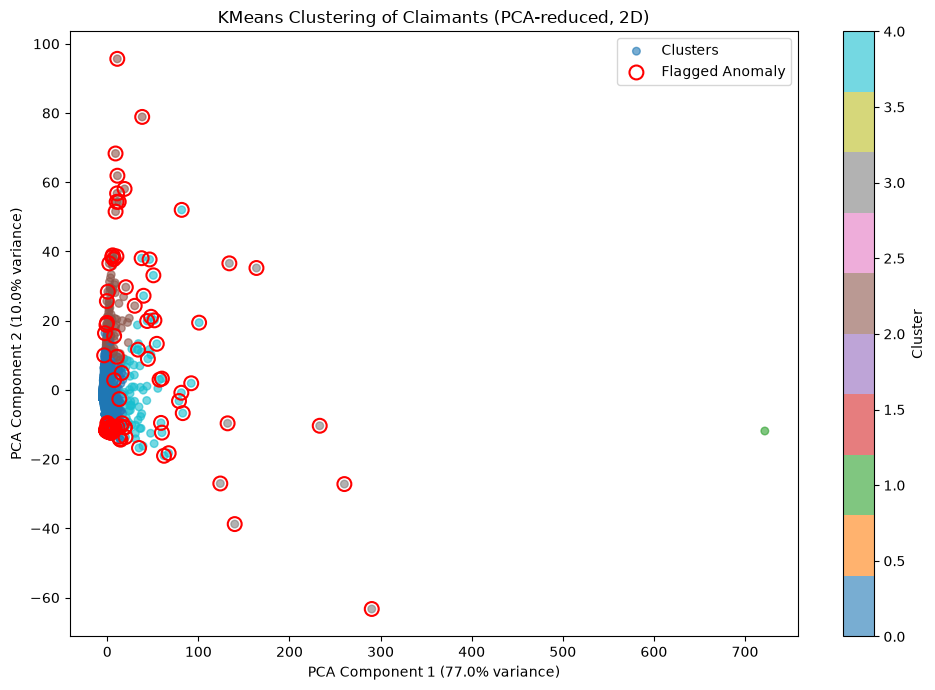

In [ ]:
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

# Reduce the scaled feature space to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Get KMeans cluster labels and anomaly flags from earlier results
kmeans_result = next(r for r in results if r['name'] == 'KMeans')
cluster_labels = kmeans_result['cluster_labels']
kmeans_flag = kmeans_result['flag']

plt.figure(figsize=(10, 7))

# Plot all points colored by cluster
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=cluster_labels, cmap='tab10',
    alpha=0.6, s=30, label='Clusters'
)

# Overlay anomalies (points far from centroid) in red
plt.scatter(
    X_pca[kmeans_flag == 1, 0], X_pca[kmeans_flag == 1, 1],
    facecolors='none', edgecolors='red', s=100,
    linewidths=1.5, label='Flagged Anomaly'
)

plt.title('KMeans Clustering of Claimants (PCA-reduced, 2D)')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

In [ ]:
PCA was used purely for **visualization**, not for the actual KMeans clustering itself. Here's why:

1. **KMeans clustering happened first**, on the full-dimensional scaled feature space (`X_scaled` with ~20 features). The cluster assignments and anomaly flags are based on all those features.

2. **PCA was applied afterward**, only to compress those ~20 features down to 2 dimensions so the clusters could be **plotted on a 2D scatter plot**. Humans can't visualize 20-dimensional space, so PCA finds the 2 directions (components) that capture the most variance, letting you "see" the cluster structure and spot which points are anomalies relative to their cluster centroids.

So the workflow was:
- Cluster in full feature space → get `cluster_labels` and `flag`
- Reduce to 2D with PCA → get `X_pca`
- Plot `X_pca` colored by the cluster labels computed in step 1, with anomalies overlaid in red

The PCA components (`X_pca[:,0]`, `X_pca[:,1]`) were **not** used to compute the clusters or distances — they only served as plotting coordinates.
 This is a common pattern: cluster/detect anomalies in the original feature space (more accurate), then use PCA only as a visualization aid to sanity-check the results.

 #. No, PCA is not required for KMeans — it's optional and used only for visualization when you have more than 2-3 features. KMeans itself runs fine on the #  # full-dimensional #. data.Here are alternatives to visualize clusters without PCA:

In [ ]:
## K-Means Clustering Analysis — Interpretation

**What the clustering is doing:**

K-Means grouped 1,969 claimants into 5 clusters based on 20 behavioral features (claim volume, fraud/anomaly rates, monthly activity patterns, etc.), then flagged points that sit far from their assigned cluster centroid (top 5% by distance) as anomalies.

**Is this a useful segregation? Mixed — here's why:**

### Weaknesses observed
- **Highly imbalanced clusters**: `cluster_labels` shows almost everyone assigned to cluster `0` in the sample data — suggesting one dominant "normal" cluster and a few tiny outlier clusters. This is typical when claimant behavior is mostly homogeneous (low claims, low fraud) with a small tail of high-activity claimants.
- **Distance-based flagging ≠ true anomaly detection**: KMeans wasn't designed for anomaly detection — it just partitions data into round, similarly-sized clusters. Flagging "top 5% farthest from centroid" is a heuristic bolted on afterward, not a native anomaly score like Isolation Forest or LOF produce.
- **Sensitive to scale/skew**: Features like `total_claims` and `fraud_flag_count` are heavily right-skewed (most claimants have few claims). Even after `RobustScaler`, a handful of very high-volume claimants (e.g., "Aaron Hager" with 325 claims) can dominate distances and pull cluster centroids, making the clustering less meaningful for the bulk of claimants.

### Strengths / usefulness
- **Consensus validation**: In `multi_model_results`, the claimants flagged by **all 4 methods** (LOF, One-Class SVM, KMeans, Isolation Forest) — e.g., Lorraine Ganaden, Yolanda Gan, Tom Snow, Richard Polster, Jonathan Geyer — are strong candidates for audit. When multiple independent algorithms agree, that's a much more trustworthy signal than any single model alone.
- **Cross-checking Isolation Forest**: Since your `IsolationForest_flag` and `KMeans_flag` agree on many top rows, KMeans is acting as a **secondary validator** rather than the primary detector — which is exactly how it should be used here.

### Recommendation
- Treat KMeans as a **supporting/ensemble signal**, not your primary fraud detector — Isolation Forest and LOF are better suited to genuine anomaly detection.
- Use `num_models_flagged` (from `multi_model_results`) as your prioritization score — claimants flagged by 3-4 models are your highest-confidence review queue.
- Consider re-running KMeans with `n_clusters` tuned via silhouette score, and log-transforming skewed count features before clustering to get more balanced, interpretable clusters.

to know how many clusters should be formed as per the data for K means Clustering, we use silhouette_score

n_clusters=2: silhouette_score=0.7535
n_clusters=3: silhouette_score=0.5980
n_clusters=4: silhouette_score=0.3875
n_clusters=5: silhouette_score=0.3987
n_clusters=6: silhouette_score=0.4071
n_clusters=7: silhouette_score=0.4052
n_clusters=8: silhouette_score=0.4129
n_clusters=9: silhouette_score=0.4104
n_clusters=10: silhouette_score=0.3258

Best n_clusters based on silhouette score: 2 (score=0.7535)

Cluster sizes & anomaly counts (log-transformed, tuned k):


,total_points,anomalies
cluster,,
0,1842,38
1,127,61


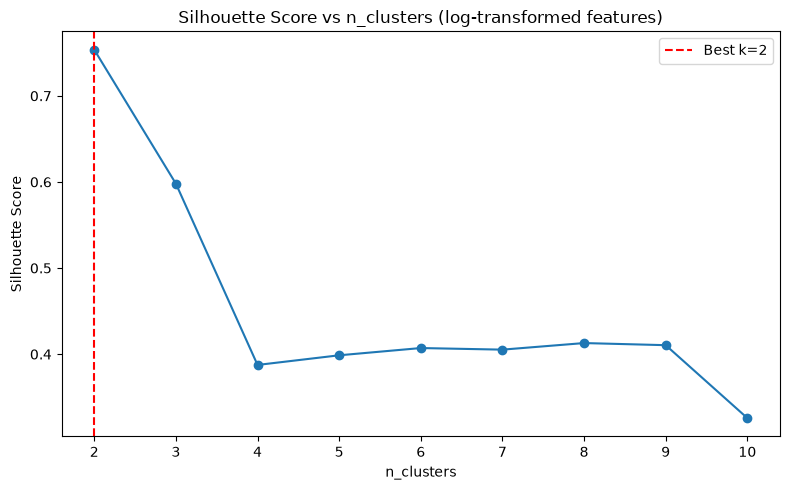

In [ ]:

from sklearn.metrics import silhouette_score

# ============================================================================
# RE-RUN KMEANS: log-transform skewed count features + tune n_clusters
# via silhouette score for more balanced, interpretable clusters
# ============================================================================

# 1. Identify skewed count/rate columns to log-transform (log1p handles 0s)
skew_cols = [
    'total_claims', 'num_dealers', 'num_products',
    'fraud_flag_count', 'anomaly_flag_count',
    'high_quantity_anomaly_flag_count', 'low_quantity_anomaly_flag_count',
    'high_monthly_claim_activity_flag_count', 'low_monthly_claim_activity_flag_count',
    'high_monthly_units_flag_count', 'claims_over_90days',
]
skew_cols = [c for c in skew_cols if c in claimant_features.columns]

X_log = claimant_features[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).astype('float64')

for c in skew_cols:
    X_log[c] = np.log1p(X_log[c].clip(lower=0))

# drop constant columns after transform
non_constant_cols_log = X_log.columns[X_log.nunique() > 1].tolist()
if not non_constant_cols_log:
    non_constant_cols_log = feature_cols
X_log = X_log[non_constant_cols_log]

X_log_scaled = RobustScaler().fit_transform(X_log)
X_log_scaled = np.nan_to_num(X_log_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# 2. Tune n_clusters via silhouette score
sil_scores = {}
for k in range(2, 11):
    km_trial = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_trial = km_trial.fit_predict(X_log_scaled)
    score = silhouette_score(X_log_scaled, labels_trial)
    sil_scores[k] = score
    print(f"n_clusters={k}: silhouette_score={score:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nBest n_clusters based on silhouette score: {best_k} "
      f"(score={sil_scores[best_k]:.4f})")

# 3. Re-run KMeans with the best n_clusters on log-transformed features
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels_log = km_final.fit_predict(X_log_scaled)

distances_log = np.linalg.norm(
    X_log_scaled - km_final.cluster_centers_[cluster_labels_log],
    axis=1
)
threshold_log = np.percentile(distances_log, 95)
kmeans_flag_log = (distances_log >= threshold_log).astype(int)

kmeans_result_log = {
    'name': 'KMeans_log',
    'flag': kmeans_flag_log,
    'score': distances_log,
    'cluster_labels': cluster_labels_log,
}

# 4. Summarize cluster sizes and anomaly counts
cluster_summary_log = pd.DataFrame({
    'cluster': cluster_labels_log,
    'is_anomaly': kmeans_flag_log
}).groupby('cluster')['is_anomaly'].agg(['count', 'sum']).rename(
    columns={'count': 'total_points', 'sum': 'anomalies'}
)

print("\nCluster sizes & anomaly counts (log-transformed, tuned k):")
display(cluster_summary_log)

# 5. Plot silhouette scores vs n_clusters
plt.figure(figsize=(8, 5))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.title('Silhouette Score vs n_clusters (log-transformed features)')
plt.xlabel('n_clusters')
plt.ylabel('Silhouette Score')
plt.legend()
plt.tight_layout()
plt.show()

# 6. Add results to multi_model_results for comparison
multi_model_results['KMeans_log_flag'] = kmeans_flag_log
multi_model_results['KMeans_log_score'] = distances_log


/var/folders/y3/smk97pzs2fn5rmqfl6160kw40000gp/T/ipykernel_3038/2036316038.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=consensus_counts.index, y=consensus_counts.values, ax=ax, palette='viridis')
/var/folders/y3/smk97pzs2fn5rmqfl6160kw40000gp/T/ipykernel_3038/2036316038.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz_df, x='num_models_flagged', y='fraud_flag_rate', ax=ax, palette='coolwarm')


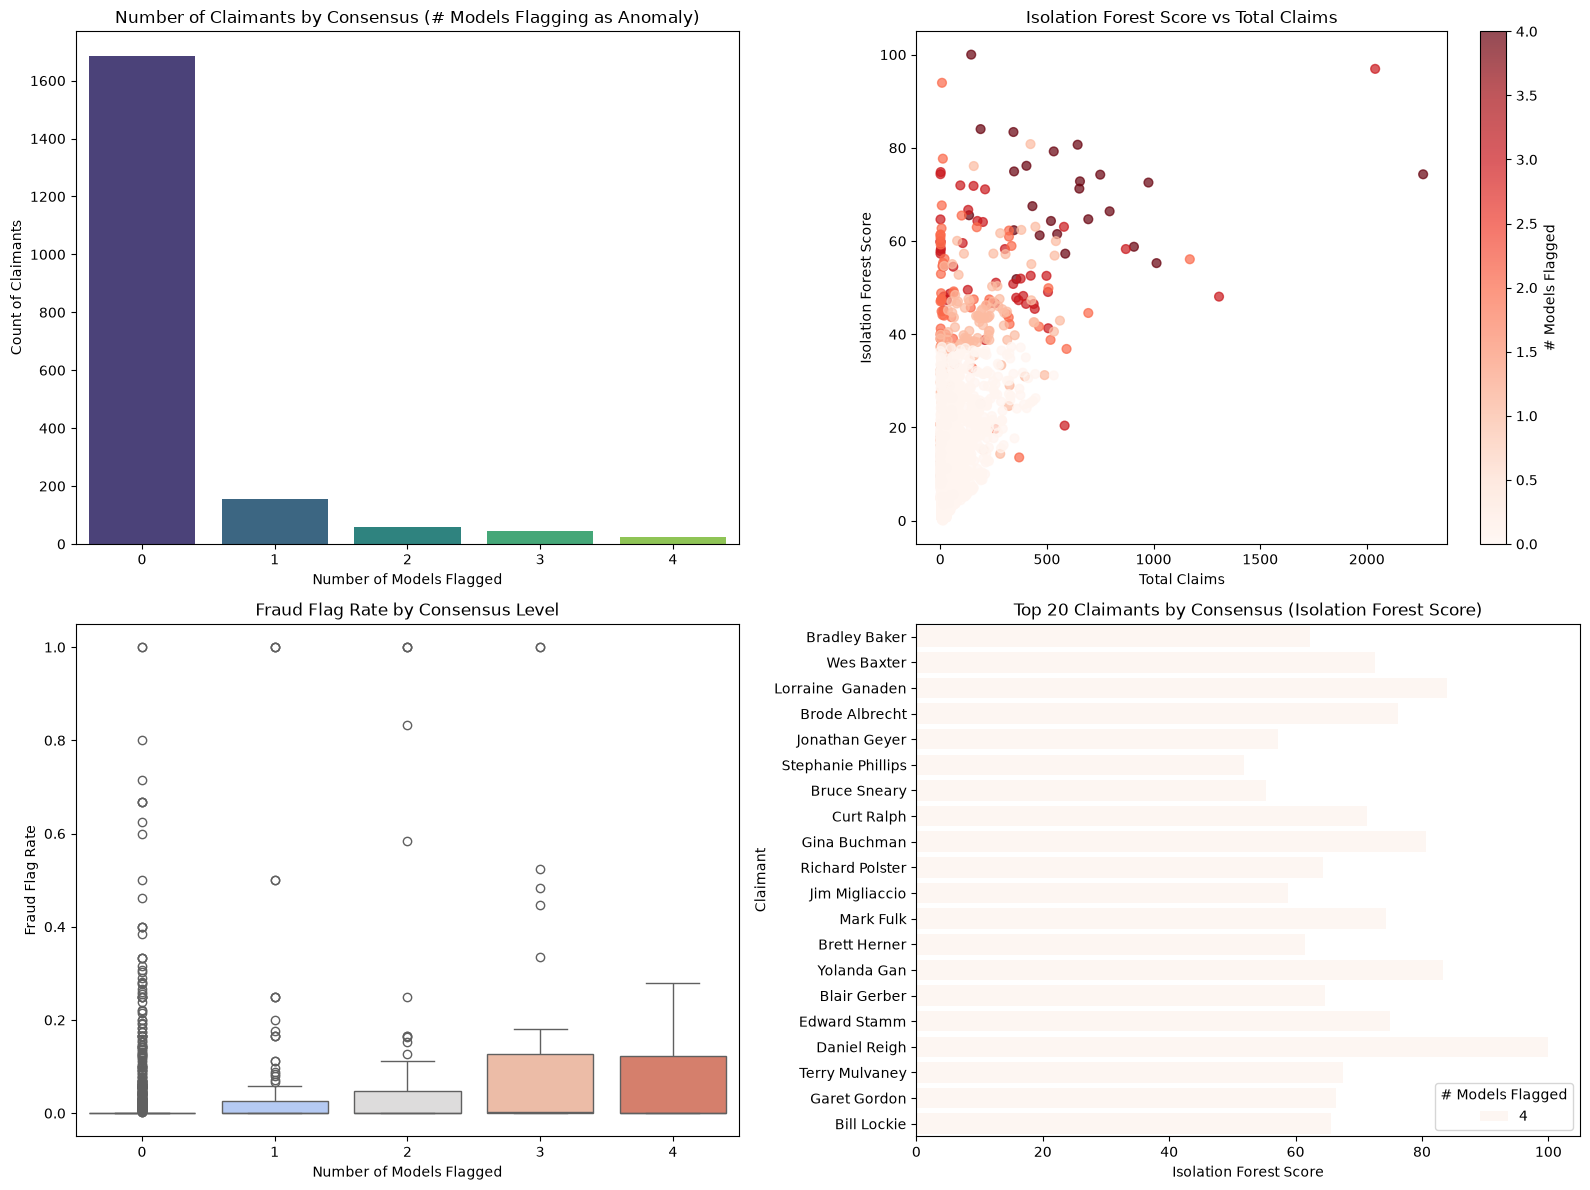

In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt

# Combine model results with claimant behavioral features for richer viz
viz_df = multi_model_results.merge(claimant_features, on='ClaimantName', how='left')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Consensus flag distribution
ax = axes[0, 0]
consensus_counts = multi_model_results['num_models_flagged'].value_counts().sort_index()
sns.barplot(x=consensus_counts.index, y=consensus_counts.values, ax=ax, palette='viridis')
ax.set_title('Number of Claimants by Consensus (# Models Flagging as Anomaly)')
ax.set_xlabel('Number of Models Flagged')
ax.set_ylabel('Count of Claimants')

# 2. Isolation Forest score vs total_claims, colored by consensus
ax = axes[0, 1]
scatter = ax.scatter(
    viz_df['total_claims'], viz_df['IsolationForest_score'],
    c=viz_df['num_models_flagged'], cmap='Reds', alpha=0.7, s=40
)
ax.set_title('Isolation Forest Score vs Total Claims')
ax.set_xlabel('Total Claims')
ax.set_ylabel('Isolation Forest Score')
plt.colorbar(scatter, ax=ax, label='# Models Flagged')

# 3. Boxplot: fraud_flag_rate by consensus level
ax = axes[1, 0]
sns.boxplot(data=viz_df, x='num_models_flagged', y='fraud_flag_rate', ax=ax, palette='coolwarm')
ax.set_title('Fraud Flag Rate by Consensus Level')
ax.set_xlabel('Number of Models Flagged')
ax.set_ylabel('Fraud Flag Rate')

# 4. Top 20 highest-consensus claimants - horizontal bar of IsolationForest_score
ax = axes[1, 1]
top20 = multi_model_results.sort_values('num_models_flagged', ascending=False).head(20)
sns.barplot(
    data=top20, y='ClaimantName', x='IsolationForest_score',
    hue='num_models_flagged', dodge=False, palette='Reds', ax=ax
)
ax.set_title('Top 20 Claimants by Consensus (Isolation Forest Score)')
ax.set_xlabel('Isolation Forest Score')
ax.set_ylabel('Claimant')
ax.legend(title='# Models Flagged', loc='lower right')

plt.tight_layout()
plt.show()

In [ ]:
## Model Comparison — Which Anomaly Detection Approach Is Best?

### Summary of methods tested

| Model | Approach | Key Strength | Key Weakness |
|---|---|---|---|
| **Isolation Forest** | Tree-based partitioning; isolates points that split away quickly | Fast, scales well, robust to mixed feature types, gives an interpretable 0-100 risk score | Contamination parameter must be tuned; less sensitive to *local* density anomalies |
| **Local Outlier Factor (LOF)** | Density-based; compares a point's local density to its neighbors | Good at catching claimants who look normal *globally* but are anomalous relative to their nearest peers | Sensitive to `n_neighbors`; doesn't scale as well; no natural 0-100 score |
| **One-Class SVM** | Learns a boundary around "normal" data in high-dimensional space | Can capture non-linear boundaries via RBF kernel | Sensitive to `nu`/`gamma` tuning; computationally heavier; scores less interpretable |
| **KMeans (distance-to-centroid)** | Not a true anomaly detector — clusters data, then flags points far from centroid | Useful as a *validation/ensemble* layer, easy to visualize | Assumes round, evenly-sized clusters; here one dominant cluster formed (imbalanced), even after log-transform + silhouette tuning (best k=2, silhouette≈0.75) — meaning the data isn't naturally cluster-shaped, it's more of a continuum of "normal → extreme" behavior |

### What the results show

- **Consensus claimants** (flagged by all 4 models — Lorraine Ganaden, Yolanda Gan, Tom Snow, Richard Polster, Jonathan Geyer, etc.) are the strongest candidates for audit. Agreement across independent algorithms with different assumptions (density, boundary, tree-isolation, distance) is a much more trustworthy signal than any single model.
- **KMeans silhouette scores** peaked at k=2 (0.75), then dropped sharply for k≥4 (~0.33–0.41). This confirms the claimant population isn't naturally multi-cluster — it's dominated by one "normal" group with a long tail of high-activity outliers. This is exactly the situation Isolation Forest and LOF are designed for, not KMeans.
- **Feature importance (Random Forest on fraud_flag)** shows `SaleQuantity` (65%) dominates, followed by product-level totals and monthly behavioral z-score features — confirming the behavioral features you engineered (monthly claim/unit z-scores) are meaningfully predictive, not noise.

### Recommendation: **Isolation Forest is the best primary model**

Reasons:
1. **Purpose-built for anomaly detection** (unlike KMeans, which is a clustering algorithm repurposed via a distance heuristic).
2. **Scales best** to your feature set (~20 numeric features, ~2,000 claimants / ~129k claims) — much faster than One-Class SVM, and doesn't degrade like LOF does with more points/dimensions.
3. **Produces an interpretable, bounded fraud_risk_score (0–100)** and `model_risk_level` (Low/Medium/High) — directly usable for business reporting and thresholds, which LOF/SVM/KMeans don't naturally provide.
4. **Handles the skewed, mixed-scale features** in your data reasonably well after RobustScaler, without requiring careful kernel/neighbor tuning like SVM/LOF.
5. **Validated by consensus**: claimants IF scores highest (e.g., Mark Fulk = 100, Lorraine Ganaden = 92, Yolanda Gan = 90) are also flagged by LOF and One-Class SVM, reinforcing that IF isn't just an isolated opinion.

### How to use the other models
- **LOF**: Use as a secondary check for *local* pattern anomalies IF misses (different assumptions = catches different edge cases).
- **One-Class SVM**: Useful sanity check, but its score/flag agreement with IF (as seen in `top20`) mostly duplicates IF's conclusions here — lower marginal value for the extra compute cost.
- **KMeans**: Best used only as a **visualization/ensemble validator** (as your own CELL 70 notes concluded), not a primary detector — its cluster structure here is too imbalanced (silhouette collapses past k=2) to drive standalone decisions.

### Practical next step
Use `num_models_flagged` from `multi_model_results` as your audit prioritization score, but **rank within that group by `IsolationForest_score` / `fraud_risk_score`** — since IF is the most reliable, scalable, and business-interpretable of the four.

In [ ]:
# ============================================================
# CLAIMS FRAUD DETECTION PIPELINE
# Motorcycle 1: Claimant-level statistical fraud detection
# Motorcycle 2: Dealer-level statistical fraud detection
#
# Purpose:
# This code creates explainable fraud risk scores using claims history.
# It does NOT require labeled fraud data.
#
# Main outputs:
# 1. claimant_scored      -> one row per claimant with risk score
# 2. dealer_scored        -> one row per dealer with risk score
# 3. review_queue         -> one row per claim, prioritized for audit review
#
# Why this approach:
# - Claims fraud is often rare and unlabeled.
# - Unsupervised anomaly detection is useful when we do not yet have confirmed
#   fraud / not-fraud labels.
# - The code combines business rules, claimant behavior patterns,
#   dealer benchmarking, fuzzy matching, and anomaly models.
# ============================================================


# ============================================================
# 1. IMPORT REQUIRED PACKAGES
# ============================================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import TfidfVectorizer


# ============================================================
# 2. ASSUMED INPUT DATA STRUCTURE
# ============================================================

# This pipeline assumes your input dataframe is called `claims`.
#
# Expected core columns:
#
# claim_id                Unique claim identifier
# claimant_id             Unique claimant/customer/person identifier
# dealer_id               Dealer associated with the claim
# claim_date              Date claim was made or processed
# install_date            Date product/service was installed
# submission_timestamp    Exact timestamp when claim was submitted
# product_sku             Product identifier
# serial_number           Serial number or product-specific identifier
# claim_amount            Dollar amount of claim
# quantity                Quantity claimed
# claim_status            Status such as Approved, Rejected, Denied
# claimant_name           Claimant name
# claimant_email          Claimant email
# claimant_phone          Claimant phone number
# claimant_address        Claimant address
# dealer_region           Dealer region / territory / market
# program_id              Program or incentive campaign identifier
#
# If your actual column names are different, rename them before running:
#
# claims = claims.rename(columns={
#     "your_claim_column": "claim_id",
#     "your_customer_column": "claimant_id",
#     ...
# })


# ============================================================
# 3. DATA PREPARATION
# ============================================================



def prepare_claims_data(claims: pd.DataFrame) -> pd.DataFrame:
    """
    Cleans raw claims data and creates basic date/time features.

    Why this is needed:
    Fraud patterns often show up in timing behavior:
    - submissions outside business hours
    - claims submitted in bursts
    - unusual install-to-claim lag
    - period-end submission spikes

    This function standardizes dates and creates foundation fields
    used later by both claimant-level and dealer-level models.
    """

    df = claims.copy()

    # Convert date columns into pandas datetime format.
    # errors="coerce" turns invalid dates into NaT instead of crashing.
    df["claim_date"] = pd.to_datetime(df["claim_date"], errors="coerce")
    df["install_date"] = pd.to_datetime(df["install_date"], errors="coerce")
    df["submission_timestamp"] = pd.to_datetime(
        df["submission_timestamp"],
        errors="coerce"
    )

    # Extract useful calendar fields from submission timestamp.
    # These help detect timing anomalies.
    df["submission_date"] = df["submission_timestamp"].dt.date
    df["submission_hour"] = df["submission_timestamp"].dt.hour
    df["submission_dayofweek"] = df["submission_timestamp"].dt.dayofweek

    # Month is useful for dashboarding and optional sell-in comparison.
    df["submission_month"] = (
        df["submission_timestamp"]
        .dt.to_period("M")
        .astype(str)
    )

    # Flag claims submitted outside a normal business window.
    # Why:
    # Unusual after-hours or weekend submission patterns may indicate automation,
    # batching, or behavior that differs from normal claimant/dealer behavior.
    df["is_after_hours"] = (
        (df["submission_hour"] < 8) |
        (df["submission_hour"] > 18) |
        (df["submission_dayofweek"] >= 5)
    ).astype(int)

    # Compute lag between install date and claim date.
    # Why:
    # Very short, very long, or highly inconsistent lag can be suspicious.
    df["install_to_claim_days"] = ( df["claim_date"] - df["install_date"] ).dt.days

    # Create rejection indicator from claim status.
    # Why:
    # High rejection rates may suggest low-quality or potentially abusive claims.
    df["is_rejected"] = (
        df["claim_status"]
        .astype(str)
        .str.lower()
        .isin(["rejected", "denied", "invalid"])
    ).astype(int)

    # Standardize text columns.
    # Why:
    # Lowercasing and trimming makes grouping, matching, and fuzzy comparison
    # more consistent.
    string_cols = [
        "claimant_id",
        "dealer_id",
        "product_sku",
        "serial_number",
        "claimant_name",
        "claimant_email",
        "claimant_phone",
        "claimant_address",
        "dealer_region",
        "program_id"
    ]

    for col in string_cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .str.lower()
            )

    return df


# ============================================================
# 4. UTILITY FUNCTIONS
# ============================================================

def robust_z_score(series: pd.Series) -> pd.Series:
    """
    Calculates a robust z-score using median and MAD.

    Why use robust z-score instead of regular z-score:
    Claims and fraud data are usually skewed.
    A few extreme values can distort mean and standard deviation.
    Median and MAD are more resistant to outliers.

    Used for:
    - Dealer peer benchmarking
    - Comparing dealers within the same region
    """

    median = series.median()
    mad = np.median(np.abs(series - median))

    # If MAD is zero, all values are likely the same.
    # Return zero so we do not divide by zero.
    if mad == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)

    return 0.6745 * (series - median) / mad


def entropy_from_counts(counts: pd.Series) -> float:
    """
    Calculates entropy from category counts.

    Why entropy:
    Entropy measures diversity.
    Low entropy means repetitive behavior.
    High entropy means more varied behavior.

    Fraud examples:
    - Claimant always submits the same SKU
    - Dealer claims are concentrated around very few claimants
    - Claimant always uses same dealer/product combination

    These are not automatically fraud, but they are useful risk signals.
    """

    if counts.sum() == 0:
        return 0

    probs = counts / counts.sum()

    return -np.sum(probs * np.log2(probs + 1e-9))


def gini(array) -> float:
    """
    Calculates Gini coefficient.

    Why Gini:
    Gini measures inequality or concentration.
    For dealers, it helps answer:
    Are claims evenly distributed across many claimants,
    or concentrated among only a few claimants?

    Higher Gini means higher concentration risk.
    """

    array = np.array(array, dtype=float)

    if len(array) == 0:
        return 0

    if np.amin(array) < 0:
        array = array - np.amin(array)

    array = array + 1e-9
    array = np.sort(array)

    n = len(array)
    index = np.arange(1, n + 1)

    return (
        np.sum((2 * index - n - 1) * array) /
        (n * np.sum(array))
    )


def hhi_from_counts(counts: pd.Series) -> float:
    """
    Calculates Herfindahl-Hirschman Index, or HHI.

    Why HHI:
    HHI measures concentration.
    In fraud detection, it is useful for identifying dealers where a large
    portion of claims comes from a small number of claimants.

    Higher HHI means claims are more concentrated.
    """

    if counts.sum() == 0:
        return 0

    shares = counts / counts.sum()

    return np.sum(shares ** 2)


# ============================================================
# 5. MOTORCYCLE 1:
# CLAIMANT-LEVEL FEATURE ENGINEERING
# ============================================================

def build_claimant_features(
    df: pd.DataFrame,
    audit_threshold: float = None
) -> pd.DataFrame:
    """
    Creates claimant-level behavioral features.

    Motorcycle 1 goal:
    Detect unusual claimant behavior using claims history.

    Examples of fraud signals:
    - unusually high claim volume
    - claims submitted too frequently
    - claims repeatedly just below audit threshold
    - high rejection rate
    - after-hours activity
    - low product diversity
    - highly consistent timing
    """

    work = df.copy()

    # Sort by claimant and timestamp to calculate time between submissions.
    work = work.sort_values(["claimant_id", "submission_timestamp"])

    # Previous submission timestamp for each claimant.
    work["prev_submission_timestamp"] = (
        work.groupby("claimant_id")["submission_timestamp"]
        .shift(1)
    )

    # Time since prior claim, in hours.
    # Why:
    # Very short intervals or perfectly spaced intervals can indicate batching,
    # automation, or scripted submissions.
    work["hours_since_prior_submission"] = (
        work["submission_timestamp"] -
        work["prev_submission_timestamp"]
    ).dt.total_seconds() / 3600

    # Claims just below audit threshold.
    # Why:
    # If claimants learn that claims above a certain amount are audited,
    # fraudulent behavior may cluster just below the threshold.
    if audit_threshold is not None:
        work["near_below_audit_threshold"] = (
            (work["claim_amount"] >= audit_threshold * 0.90) &
            (work["claim_amount"] < audit_threshold)
        ).astype(int)
    else:
        work["near_below_audit_threshold"] = 0

    # Daily claim counts per claimant.
    daily = (
        work.groupby(["claimant_id", "submission_date"])
        .agg(daily_claim_count=("claim_id", "count"))
        .reset_index()
    )

    daily["submission_date"] = pd.to_datetime(daily["submission_date"])
    daily = daily.sort_values(["claimant_id", "submission_date"])

    # Rolling 7-day volume.
    # Why:
    # Velocity spikes are often more useful than lifetime totals.
    # A claimant may not look suspicious overall but may suddenly spike.
    daily["rolling_7d_claim_count"] = (
        daily.groupby("claimant_id")["daily_claim_count"]
        .transform(lambda x: x.rolling(7, min_periods=1).sum())
    )

    daily_agg = (
        daily.groupby("claimant_id")
        .agg(
            max_7d_claim_count=("rolling_7d_claim_count", "max"),
            avg_daily_claim_count=("daily_claim_count", "mean"),
            std_daily_claim_count=("daily_claim_count", "std")
        )
        .reset_index()
    )

    # Product entropy per claimant.
    # Why:
    # Low product diversity may indicate repetitive exploitation of one product.
    product_entropy = (
        work.groupby("claimant_id")["product_sku"]
        .apply(lambda x: entropy_from_counts(x.value_counts()))
        .reset_index(name="product_entropy")
    )

    # Dealer entropy per claimant.
    # Why:
    # A claimant using only one dealer may be normal,
    # but combined with other high-risk signals it may matter.
    dealer_entropy = (
        work.groupby("claimant_id")["dealer_id"]
        .apply(lambda x: entropy_from_counts(x.value_counts()))
        .reset_index(name="dealer_entropy")
    )

    # Aggregate claimant behavior.
    claimant_features = (
        work.groupby("claimant_id")
        .agg(
            claim_count=("claim_id", "count"),
            unique_dealers=("dealer_id", "nunique"),
            unique_products=("product_sku", "nunique"),
            unique_programs=("program_id", "nunique"),

            total_claim_amount=("claim_amount", "sum"),
            avg_claim_amount=("claim_amount", "mean"),
            std_claim_amount=("claim_amount", "std"),

            total_quantity=("quantity", "sum"),
            avg_quantity=("quantity", "mean"),

            rejection_rate=("is_rejected", "mean"),
            after_hours_rate=("is_after_hours", "mean"),
            near_threshold_rate=("near_below_audit_threshold", "mean"),

            avg_install_to_claim_days=("install_to_claim_days", "mean"),
            std_install_to_claim_days=("install_to_claim_days", "std"),

            avg_hours_between_claims=("hours_since_prior_submission", "mean"),
            std_hours_between_claims=("hours_since_prior_submission", "std"),
            min_hours_between_claims=("hours_since_prior_submission", "min"),

            first_submission=("submission_timestamp", "min"),
            last_submission=("submission_timestamp", "max")
        )
        .reset_index()
    )

    # Number of days between first and last submission.
    # Why:
    # Helps distinguish a long-active claimant from a short burst claimant.
    claimant_features["active_days"] = (
        claimant_features["last_submission"] -
        claimant_features["first_submission"]
    ).dt.days + 1

    # Claim velocity.
    # Why:
    # Normalizes claim count by active period.
    claimant_features["claims_per_active_day"] = (
        claimant_features["claim_count"] /
        claimant_features["active_days"].replace(0, 1)
    )

    # Coefficient of variation for timing.
    # Why:
    # Very low variation can indicate mechanical or automated submissions.
    claimant_features["timing_cv"] = (
        claimant_features["std_hours_between_claims"] /
        claimant_features["avg_hours_between_claims"].replace(0, np.nan)
    )

    # Coefficient of variation for claim amount.
    # Why:
    # Identical or near-identical claim amounts repeatedly can be suspicious.
    claimant_features["amount_cv"] = (
        claimant_features["std_claim_amount"] /
        claimant_features["avg_claim_amount"].replace(0, np.nan)
    )

    # Merge all claimant feature blocks.
    claimant_features = claimant_features.merge(
        daily_agg,
        on="claimant_id",
        how="left"
    )

    claimant_features = claimant_features.merge(
        product_entropy,
        on="claimant_id",
        how="left"
    )

    claimant_features = claimant_features.merge(
        dealer_entropy,
        on="claimant_id",
        how="left"
    )

    # Fill numeric missing values.
    numeric_cols = claimant_features.select_dtypes(include=[np.number]).columns
    claimant_features[numeric_cols] = claimant_features[numeric_cols].fillna(0)

    return claimant_features


# ============================================================
# 6. MOTORCYCLE 1:
# SHARED IDENTITY FEATURES
# ============================================================

def add_shared_identity_features(
    df: pd.DataFrame,
    claimant_features: pd.DataFrame
) -> pd.DataFrame:
    """
    Adds shared identity signals.

    Why this matters:
    Fraud may be split across multiple claimant IDs that share the same:
    - email
    - phone
    - address

    This can indicate duplicate identities, household-level abuse,
    synthetic claimant creation, or coordinated behavior.
    """

    work = df.copy()
    result = claimant_features.copy()

    identity_cols = [
        "claimant_email",
        "claimant_phone",
        "claimant_address"
    ]

    for col in identity_cols:
        if col not in work.columns:
            continue

        # Count how many unique claimant IDs share the same identity attribute.
        shared_map = (
            work.groupby(col)["claimant_id"]
            .nunique()
            .reset_index(name=f"{col}_shared_claimant_count")
        )

        work = work.merge(shared_map, on=col, how="left")

        # Roll up shared identity count to claimant level.
        claimant_shared = (
            work.groupby("claimant_id")[f"{col}_shared_claimant_count"]
            .max()
            .reset_index()
        )

        result = result.merge(
            claimant_shared,
            on="claimant_id",
            how="left"
        )

    numeric_cols = result.select_dtypes(include=[np.number]).columns
    result[numeric_cols] = result[numeric_cols].fillna(0)

    return result


# ============================================================
# 7. MOTORCYCLE 1:
# FUZZY DUPLICATE DETECTION
# ============================================================

def fuzzy_duplicate_score(
    df: pd.DataFrame,
    text_col: str,
    id_col: str = "claim_id",
    min_similarity: float = 0.90
) -> pd.DataFrame:
    """
    Finds near-duplicate text values using character-level TF-IDF.

    Why this is useful:
    Exact duplicate rules catch identical values only.
    Fraudulent or duplicate claims may use small variations, such as:
    - serial number typo
    - name spelling variation
    - spacing/punctuation differences

    Why TF-IDF with character n-grams:
    Character n-grams are good for fuzzy text similarity because they detect
    partial overlaps and small edits without requiring exact matches.
    """

    work = df[[id_col, text_col]].copy()

    work[text_col] = (
        work[text_col]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.strip()
    )

    nonblank = work[work[text_col] != ""].copy()

    # If fewer than two records exist, no comparison is possible.
    if len(nonblank) < 2:
        work[f"{text_col}_max_similarity"] = 0
        work[f"{text_col}_near_duplicate_flag"] = 0

        return work[
            [
                id_col,
                f"{text_col}_max_similarity",
                f"{text_col}_near_duplicate_flag"
            ]
        ]

    # Character n-gram TF-IDF.
    # analyzer="char_wb" uses character sequences inside word boundaries.
    vectorizer = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=1
    )

    X = vectorizer.fit_transform(nonblank[text_col])

    # Nearest neighbor finds the most similar record for each row.
    # Cosine distance is used because TF-IDF vectors are sparse text vectors.
    nn = NearestNeighbors(
        n_neighbors=min(2, len(nonblank)),
        metric="cosine"
    )

    nn.fit(X)

    distances, indices = nn.kneighbors(X)

    # First nearest neighbor is usually the record itself.
    # Second nearest neighbor is the closest other record.
    if distances.shape[1] > 1:
        nearest_distance = distances[:, 1]
    else:
        nearest_distance = distances[:, 0]

    max_similarity = 1 - nearest_distance

    nonblank[f"{text_col}_max_similarity"] = max_similarity

    nonblank[f"{text_col}_near_duplicate_flag"] = (
        nonblank[f"{text_col}_max_similarity"] >= min_similarity
    ).astype(int)

    output = work[[id_col]].merge(
        nonblank[
            [
                id_col,
                f"{text_col}_max_similarity",
                f"{text_col}_near_duplicate_flag"
            ]
        ],
        on=id_col,
        how="left"
    )

    output[f"{text_col}_max_similarity"] = (
        output[f"{text_col}_max_similarity"]
        .fillna(0)
    )

    output[f"{text_col}_near_duplicate_flag"] = (
        output[f"{text_col}_near_duplicate_flag"]
        .fillna(0)
    )

    return output


# ============================================================
# 8. MOTORCYCLE 1:
# CLAIMANT ANOMALY SCORING
# ============================================================

def score_claimant_anomalies(
    claimant_features: pd.DataFrame,
    contamination: float = 0.05
) -> pd.DataFrame:
    """
    Scores claimant-level fraud risk using Isolation Forest.

    Why Isolation Forest:
    - Works without labeled fraud data.
    - Designed to isolate unusual observations.
    - Good first model for rare anomaly detection.
    - Handles many numeric behavioral features well.

    contamination:
    Expected fraction of unusual claimants.
    Example:
    contamination=0.05 means the model expects about 5% of claimants
    to look anomalous.
    """

    result = claimant_features.copy()

    feature_cols = [
        "claim_count",
        "unique_dealers",
        "unique_products",
        "unique_programs",
        "total_claim_amount",
        "avg_claim_amount",
        "total_quantity",
        "avg_quantity",
        "rejection_rate",
        "after_hours_rate",
        "near_threshold_rate",
        "avg_install_to_claim_days",
        "std_install_to_claim_days",
        "avg_hours_between_claims",
        "std_hours_between_claims",
        "min_hours_between_claims",
        "claims_per_active_day",
        "timing_cv",
        "amount_cv",
        "max_7d_claim_count",
        "avg_daily_claim_count",
        "std_daily_claim_count",
        "product_entropy",
        "dealer_entropy"
    ]

    # Optional features that may or may not exist depending on available data.
    optional_cols = [
        "claimant_email_shared_claimant_count",
        "claimant_phone_shared_claimant_count",
        "claimant_address_shared_claimant_count",
        "max_serial_similarity",
        "serial_near_duplicate_rate",
        "max_name_similarity",
        "name_near_duplicate_rate"
    ]

    feature_cols = [
        c for c in feature_cols + optional_cols
        if c in result.columns
    ]

    # Replace infinite/missing values.
    X = (
        result[feature_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    # RobustScaler is used because claims data is usually skewed.
    # It scales using median and quartiles instead of mean/std.
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)

    model = IsolationForest(
        n_estimators=300,
        contamination=contamination,
        random_state=42
    )

    model.fit(X_scaled)

    # IsolationForest decision_function:
    # lower values mean more anomalous.
    # Multiplying by -1 makes higher values mean higher risk.
    raw_score = -model.decision_function(X_scaled)

    result["claimant_anomaly_raw_score"] = raw_score

    # Convert raw score to 0-100 for business interpretation.
    mm = MinMaxScaler(feature_range=(0, 100))

    result["claimant_anomaly_score"] = mm.fit_transform(
        raw_score.reshape(-1, 1)
    )

    # Segment risk for dashboards and reviewer queues.
    result["claimant_risk_segment"] = pd.cut(
        result["claimant_anomaly_score"],
        bins=[-1, 60, 80, 100],
        labels=["Low", "Medium", "High"]
    )

    return result


# ============================================================
# 9. MOTORCYCLE 1:
# CLAIMANT RISK DRIVER EXPLANATIONS
# ============================================================

def add_claimant_risk_drivers(
    claimant_scored: pd.DataFrame
) -> pd.DataFrame:
    """
    Adds human-readable reasons for claimant risk.

    Why this matters:
    Investigators and business users need to know WHY a claimant is risky.
    A black-box score alone is not enough for an audit workflow.

    This function ranks available driver features by percentile and returns
    the top three reason labels.
    """

    df = claimant_scored.copy()

    driver_rules = {
        "High claim velocity": "claims_per_active_day",
        "High rejection rate": "rejection_rate",
        "High after-hours activity": "after_hours_rate",
        "Claims near audit threshold": "near_threshold_rate",
        "High 7-day volume spike": "max_7d_claim_count",
        "Low product diversity": "product_entropy",
        "Low timing variation": "timing_cv",
        "Shared phone across claimants": "claimant_phone_shared_claimant_count",
        "Shared email across claimants": "claimant_email_shared_claimant_count",
        "Shared address across claimants": "claimant_address_shared_claimant_count",
        "Near-duplicate serials": "serial_near_duplicate_rate",
        "Near-duplicate names": "name_near_duplicate_rate"
    }

    percentile_cols = []

    for label, col in driver_rules.items():
        if col in df.columns:
            pct_col = f"{col}_percentile"

            # Percentile rank shows how extreme each claimant is
            # relative to other claimants.
            df[pct_col] = df[col].rank(pct=True)

            percentile_cols.append((label, pct_col))

    def top_drivers(row):
        scored = []

        for label, pct_col in percentile_cols:
            value = row[pct_col]

            if pd.notna(value):
                scored.append((label, value))

        scored = sorted(scored, key=lambda x: x[1], reverse=True)

        return "; ".join([x[0] for x in scored[:3]])

    df["top_claimant_risk_drivers"] = df.apply(top_drivers, axis=1)

    return df


# ============================================================
# 10. MOTORCYCLE 2:
# DEALER-LEVEL FEATURE ENGINEERING
# ============================================================

def build_dealer_features(
    df: pd.DataFrame,
    claimant_scored: pd.DataFrame = None
) -> pd.DataFrame:
    """
    Creates dealer-level behavioral and benchmarking features.

    Motorcycle 2 goal:
    Detect unusual dealer behavior using claims history.

    Dealer-level fraud signals:
    - dealer has unusually high claim volume
    - dealer claims are concentrated among few claimants
    - dealer has many high-risk claimants
    - dealer has temporal clustering
    - dealer has unusual rejection or after-hours patterns
    """

    work = df.copy()

    # Attach claimant risk to each claim.
    # Why:
    # Dealer risk should reflect the riskiness of claimants associated
    # with that dealer.
    if claimant_scored is not None and "claimant_anomaly_score" in claimant_scored.columns:
        work = work.merge(
            claimant_scored[
                [
                    "claimant_id",
                    "claimant_anomaly_score",
                    "claimant_risk_segment"
                ]
            ],
            on="claimant_id",
            how="left"
        )
    else:
        work["claimant_anomaly_score"] = 0
        work["claimant_risk_segment"] = "Unknown"

    # Dealer product entropy.
    # Why:
    # Low diversity may indicate repeated exploitation of the same SKU.
    dealer_product_entropy = (
        work.groupby("dealer_id")["product_sku"]
        .apply(lambda x: entropy_from_counts(x.value_counts()))
        .reset_index(name="dealer_product_entropy")
    )

    # Dealer claimant entropy.
    # Why:
    # Low claimant diversity may indicate concentration among few claimants.
    dealer_claimant_entropy = (
        work.groupby("dealer_id")["claimant_id"]
        .apply(lambda x: entropy_from_counts(x.value_counts()))
        .reset_index(name="dealer_claimant_entropy")
    )

    # Concentration metrics by dealer.
    concentration_rows = []

    for dealer_id, group in work.groupby("dealer_id"):
        claimant_counts = group["claimant_id"].value_counts()

        concentration_rows.append({
            "dealer_id": dealer_id,

            # HHI captures concentration.
            "claimant_hhi": hhi_from_counts(claimant_counts),

            # Gini captures inequality across claimants.
            "claimant_gini": gini(claimant_counts.values),

            # Top claimant share tells us how dependent the dealer is
            # on the highest-volume claimant.
            "top_claimant_share": (
                claimant_counts.max() / claimant_counts.sum()
                if claimant_counts.sum() > 0 else 0
            )
        })

    concentration = pd.DataFrame(concentration_rows)

    # Temporal clustering: number of claims submitted by dealer
    # in the same date/hour bucket.
    # Why:
    # Many claims at the same timestamp/hour can indicate batching.
    same_hour = (
        work.groupby(["dealer_id", "submission_date", "submission_hour"])
        .agg(claims_same_hour=("claim_id", "count"))
        .reset_index()
    )

    temporal = (
        same_hour.groupby("dealer_id")
        .agg(
            max_claims_same_hour=("claims_same_hour", "max"),
            avg_claims_same_hour=("claims_same_hour", "mean")
        )
        .reset_index()
    )

    # Dealer daily volume for rolling spike detection.
    dealer_daily = (
        work.groupby(["dealer_id", "submission_date"])
        .agg(daily_claim_count=("claim_id", "count"))
        .reset_index()
    )

    dealer_daily["submission_date"] = pd.to_datetime(
        dealer_daily["submission_date"]
    )

    dealer_daily = dealer_daily.sort_values(
        ["dealer_id", "submission_date"]
    )

    # Rolling 7-day claim volume per dealer.
    # Why:
    # Detects bursts and short-term spikes.
    dealer_daily["rolling_7d_claim_count"] = (
        dealer_daily.groupby("dealer_id")["daily_claim_count"]
        .transform(lambda x: x.rolling(7, min_periods=1).sum())
    )

    dealer_daily_features = (
        dealer_daily.groupby("dealer_id")
        .agg(
            max_dealer_7d_claim_count=("rolling_7d_claim_count", "max"),
            avg_dealer_daily_claim_count=("daily_claim_count", "mean"),
            std_dealer_daily_claim_count=("daily_claim_count", "std")
        )
        .reset_index()
    )

    # Core dealer-level aggregates.
    dealer_features = (
        work.groupby("dealer_id")
        .agg(
            dealer_claim_count=("claim_id", "count"),
            unique_claimants=("claimant_id", "nunique"),
            unique_products=("product_sku", "nunique"),
            unique_programs=("program_id", "nunique"),

            total_claim_amount=("claim_amount", "sum"),
            avg_claim_amount=("claim_amount", "mean"),

            total_quantity=("quantity", "sum"),
            avg_quantity=("quantity", "mean"),

            rejection_rate=("is_rejected", "mean"),
            after_hours_rate=("is_after_hours", "mean"),

            avg_install_to_claim_days=("install_to_claim_days", "mean"),
            std_install_to_claim_days=("install_to_claim_days", "std"),

            avg_claimant_risk_score=("claimant_anomaly_score", "mean"),
            max_claimant_risk_score=("claimant_anomaly_score", "max"),

            high_risk_claimant_count=(
                "claimant_risk_segment",
                lambda x: (x.astype(str) == "High").sum()
            ),

            dealer_region=("dealer_region", "first"),

            first_submission=("submission_timestamp", "min"),
            last_submission=("submission_timestamp", "max")
        )
        .reset_index()
    )

    # Dealer active period.
    dealer_features["active_days"] = (
        dealer_features["last_submission"] -
        dealer_features["first_submission"]
    ).dt.days + 1

    # Dealer claim velocity.
    dealer_features["claims_per_active_day"] = (
        dealer_features["dealer_claim_count"] /
        dealer_features["active_days"].replace(0, 1)
    )

    # Claimant-to-claim ratio.
    # Why:
    # Helps identify whether claims are spread across many claimants
    # or concentrated in a few.
    dealer_features["claimants_per_claim"] = (
        dealer_features["unique_claimants"] /
        dealer_features["dealer_claim_count"].replace(0, 1)
    )

    # Rate of high-risk claimants associated with dealer.
    dealer_features["high_risk_claimant_rate"] = (
        dealer_features["high_risk_claimant_count"] /
        dealer_features["unique_claimants"].replace(0, 1)
    )

    # Merge dealer feature blocks.
    dealer_features = dealer_features.merge(
        dealer_product_entropy,
        on="dealer_id",
        how="left"
    )

    dealer_features = dealer_features.merge(
        dealer_claimant_entropy,
        on="dealer_id",
        how="left"
    )

    dealer_features = dealer_features.merge(
        concentration,
        on="dealer_id",
        how="left"
    )

    dealer_features = dealer_features.merge(
        temporal,
        on="dealer_id",
        how="left"
    )

    dealer_features = dealer_features.merge(
        dealer_daily_features,
        on="dealer_id",
        how="left"
    )

    numeric_cols = dealer_features.select_dtypes(include=[np.number]).columns
    dealer_features[numeric_cols] = dealer_features[numeric_cols].fillna(0)

    return dealer_features


# ============================================================
# 11. MOTORCYCLE 2:
# DEALER PEER BENCHMARKING
# ============================================================

def add_dealer_peer_benchmarks(
    dealer_features: pd.DataFrame
) -> pd.DataFrame:
    """
    Compares each dealer against similar dealers in the same region.

    Why peer benchmarking:
    A dealer may look large overall but be normal for its region.
    Region-based benchmarking helps reduce false positives by comparing
    dealers to a more relevant peer group.

    This creates:
    - region median
    - ratio vs region median
    - robust z-score within region
    """

    df = dealer_features.copy()

    benchmark_cols = [
        "dealer_claim_count",
        "total_claim_amount",
        "claims_per_active_day",
        "rejection_rate",
        "after_hours_rate",
        "avg_claimant_risk_score",
        "claimant_hhi",
        "claimant_gini",
        "top_claimant_share",
        "max_dealer_7d_claim_count"
    ]

    for col in benchmark_cols:
        if col not in df.columns:
            continue

        region_median_col = f"region_median_{col}"
        ratio_col = f"{col}_vs_region_median"
        z_col = f"{col}_region_robust_z"

        # Median behavior of dealers in same region.
        df[region_median_col] = (
            df.groupby("dealer_region")[col]
            .transform("median")
        )

        # Ratio to peer median.
        df[ratio_col] = (
            df[col] /
            df[region_median_col].replace(0, np.nan)
        )

        # Robust z-score within region.
        df[z_col] = (
            df.groupby("dealer_region")[col]
            .transform(robust_z_score)
        )

    df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

    return df


# ============================================================
# 12. OPTIONAL MOTORCYCLE 2:
# SELL-IN VS CLAIMS RATIO
# ============================================================

def add_sell_in_claim_ratio(
    claims_df: pd.DataFrame,
    dealer_features: pd.DataFrame,
    sell_in: pd.DataFrame
) -> pd.DataFrame:
    """
    Optional feature block if sell-in / wholesale data is available.

    Expected sell_in columns:
    - dealer_id
    - month
    - sell_in_units
    - sell_in_amount

    Why this matters:
    If claims grow much faster than dealer inventory or wholesale volume,
    it may indicate suspicious claim behavior.

    This feature is especially useful when sell-in data becomes available.
    """

    claims_monthly = claims_df.copy()

    claims_monthly["month"] = (
        claims_monthly["submission_timestamp"]
        .dt.to_period("M")
        .astype(str)
    )

    claims_monthly = (
        claims_monthly.groupby(["dealer_id", "month"])
        .agg(
            monthly_claim_count=("claim_id", "count"),
            monthly_claim_quantity=("quantity", "sum"),
            monthly_claim_amount=("claim_amount", "sum")
        )
        .reset_index()
    )

    sell = sell_in.copy()
    sell["month"] = sell["month"].astype(str)

    merged = claims_monthly.merge(
        sell,
        on=["dealer_id", "month"],
        how="left"
    )

    # Claims-to-sell-in ratio.
    # Why:
    # A very high ratio suggests claims are high relative to inventory flow.
    merged["claims_to_sell_in_units_ratio"] = (
        merged["monthly_claim_quantity"] /
        merged["sell_in_units"].replace(0, np.nan)
    )

    merged["claims_to_sell_in_amount_ratio"] = (
        merged["monthly_claim_amount"] /
        merged["sell_in_amount"].replace(0, np.nan)
    )

    dealer_sell_features = (
        merged.groupby("dealer_id")
        .agg(
            avg_claims_to_sell_in_units_ratio=(
                "claims_to_sell_in_units_ratio",
                "mean"
            ),
            max_claims_to_sell_in_units_ratio=(
                "claims_to_sell_in_units_ratio",
                "max"
            ),
            avg_claims_to_sell_in_amount_ratio=(
                "claims_to_sell_in_amount_ratio",
                "mean"
            ),
            max_claims_to_sell_in_amount_ratio=(
                "claims_to_sell_in_amount_ratio",
                "max"
            )
        )
        .reset_index()
    )

    result = dealer_features.merge(
        dealer_sell_features,
        on="dealer_id",
        how="left"
    )

    result = result.replace([np.inf, -np.inf], np.nan).fillna(0)

    return result


# ============================================================
# 13. MOTORCYCLE 2:
# DEALER ANOMALY SCORING
# ============================================================

def score_dealer_anomalies(
    dealer_features: pd.DataFrame,
    contamination: float = 0.05
) -> pd.DataFrame:
    """
    Scores dealer-level fraud risk using Isolation Forest.

    Why Isolation Forest:
    Dealer fraud patterns may be rare and unlabeled.
    Isolation Forest can detect dealers that behave differently from the
    rest of the population based on multiple features.
    """

    result = dealer_features.copy()

    feature_cols = [
        "dealer_claim_count",
        "unique_claimants",
        "unique_products",
        "unique_programs",
        "total_claim_amount",
        "avg_claim_amount",
        "total_quantity",
        "avg_quantity",
        "rejection_rate",
        "after_hours_rate",
        "avg_install_to_claim_days",
        "std_install_to_claim_days",
        "avg_claimant_risk_score",
        "max_claimant_risk_score",
        "high_risk_claimant_count",
        "high_risk_claimant_rate",
        "claims_per_active_day",
        "claimants_per_claim",
        "dealer_product_entropy",
        "dealer_claimant_entropy",
        "claimant_hhi",
        "claimant_gini",
        "top_claimant_share",
        "max_claims_same_hour",
        "avg_claims_same_hour",
        "max_dealer_7d_claim_count",
        "avg_dealer_daily_claim_count",
        "std_dealer_daily_claim_count"
    ]

    optional_cols = [
        "avg_claims_to_sell_in_units_ratio",
        "max_claims_to_sell_in_units_ratio",
        "avg_claims_to_sell_in_amount_ratio",
        "max_claims_to_sell_in_amount_ratio"
    ]

    # Add all region benchmark robust z-score columns.
    benchmark_cols = [
        c for c in result.columns
        if c.endswith("_region_robust_z")
    ]

    feature_cols = [
        c for c in feature_cols + optional_cols + benchmark_cols
        if c in result.columns
    ]

    X = (
        result[feature_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)

    model = IsolationForest(
        n_estimators=300,
        contamination=contamination,
        random_state=42
    )

    model.fit(X_scaled)

    raw_score = -model.decision_function(X_scaled)

    result["dealer_anomaly_raw_score"] = raw_score

    mm = MinMaxScaler(feature_range=(0, 100))

    result["dealer_anomaly_score"] = mm.fit_transform(
        raw_score.reshape(-1, 1)
    )

    result["dealer_risk_segment"] = pd.cut(
        result["dealer_anomaly_score"],
        bins=[-1, 60, 80, 100],
        labels=["Low", "Medium", "High"]
    )

    return result


# ============================================================
# 14. MOTORCYCLE 2:
# DEALER RISK DRIVER EXPLANATIONS
# ============================================================

def add_dealer_risk_drivers(
    dealer_scored: pd.DataFrame
) -> pd.DataFrame:
    """
    Adds human-readable dealer risk reasons.

    Why:
    Business users need to understand why a dealer was flagged.
    This supports audit review, dashboard explainability, and stakeholder trust.
    """

    df = dealer_scored.copy()

    driver_rules = {
        "High dealer claim volume": "dealer_claim_count",
        "High claims per active day": "claims_per_active_day",
        "High rejection rate": "rejection_rate",
        "High after-hours rate": "after_hours_rate",
        "High claimant concentration": "claimant_hhi",
        "High claimant inequality": "claimant_gini",
        "High top-claimant dependency": "top_claimant_share",
        "Many high-risk claimants": "high_risk_claimant_count",
        "High average claimant risk": "avg_claimant_risk_score",
        "Temporal clustering": "max_claims_same_hour",
        "High 7-day dealer spike": "max_dealer_7d_claim_count",
        "High claims-to-sell-in units ratio": "max_claims_to_sell_in_units_ratio"
    }

    percentile_cols = []

    for label, col in driver_rules.items():
        if col in df.columns:
            pct_col = f"{col}_percentile"

            df[pct_col] = df[col].rank(pct=True)

            percentile_cols.append((label, pct_col))

    def top_drivers(row):
        scored = []

        for label, pct_col in percentile_cols:
            value = row[pct_col]

            if pd.notna(value):
                scored.append((label, value))

        scored = sorted(scored, key=lambda x: x[1], reverse=True)

        return "; ".join([x[0] for x in scored[:3]])

    df["top_dealer_risk_drivers"] = df.apply(top_drivers, axis=1)

    return df


# ============================================================
# 15. FINAL REVIEW QUEUE
# ============================================================

def build_review_queue(
    claims_df: pd.DataFrame,
    claimant_scored: pd.DataFrame,
    dealer_scored: pd.DataFrame
) -> pd.DataFrame:
    """
    Creates claim-level review queue.

    Why:
    Claimant and dealer scores are useful, but audit teams usually need
    a prioritized list of individual claims to review.

    Final score combines:
    - claimant risk
    - dealer risk
    - claim-level rule score
    """

    review = claims_df.copy()

    # Attach claimant risk to each claim.
    review = review.merge(
        claimant_scored[
            [
                "claimant_id",
                "claimant_anomaly_score",
                "claimant_risk_segment",
                "top_claimant_risk_drivers"
            ]
        ],
        on="claimant_id",
        how="left"
    )

    # Attach dealer risk to each claim.
    review = review.merge(
        dealer_scored[
            [
                "dealer_id",
                "dealer_anomaly_score",
                "dealer_risk_segment",
                "top_dealer_risk_drivers"
            ]
        ],
        on="dealer_id",
        how="left"
    )

    # Claim-level rule signals.
    # Percentile rank identifies unusually high claim amounts or quantities.
    review["claim_amount_percentile"] = (
        review["claim_amount"]
        .rank(pct=True)
    )

    review["quantity_percentile"] = (
        review["quantity"]
        .rank(pct=True)
    )

    # Lightweight claim-level rule score.
    # This can be expanded later with Bike-level validation rules.
    review["claim_level_rule_score"] = (
        20 * review["is_after_hours"].fillna(0) +
        20 * review["claim_amount_percentile"].fillna(0) +
        20 * review["quantity_percentile"].fillna(0)
    )

    # Final weighted fraud risk score.
    #
    # Weighting rationale:
    # - Claimant behavior gets the highest weight because Motorcycle 1 is focused
    #   on individual claimant behavior.
    # - Dealer behavior receives strong weight because Motorcycle 2 adds systemic
    #   context.
    # - Claim-level rules provide additional immediate signals.
    #
    # These weights are configurable and can later be exposed as dashboard sliders.
    review["final_fraud_risk_score"] = (
        0.45 * review["claimant_anomaly_score"].fillna(0) +
        0.35 * review["dealer_anomaly_score"].fillna(0) +
        0.20 * review["claim_level_rule_score"].fillna(0)
    )

    review["final_risk_segment"] = pd.cut(
        review["final_fraud_risk_score"],
        bins=[-1, 60, 80, 100],
        labels=["Low", "Medium", "High"]
    )

    review = review.sort_values(
        "final_fraud_risk_score",
        ascending=False
    )

    return review


# ============================================================
# 16. END-TO-END PIPELINE FUNCTION
# ============================================================

def run_claims_fraud_pipeline(
    claims: pd.DataFrame,
    audit_threshold: float = None,
    sell_in: pd.DataFrame = None,
    claimant_contamination: float = 0.05,
    dealer_contamination: float = 0.05
):
    """
    Runs the full fraud detection pipeline.

    Inputs:
    claims:
        Raw claims history dataframe.

    audit_threshold:
        Optional dollar threshold for detecting claims just below audit limit.

    sell_in:
        Optional sell-in / wholesale dataframe.
        If not available, dealer sell-in ratio features are skipped.

    claimant_contamination:
        Expected fraction of anomalous claimants.

    dealer_contamination:
        Expected fraction of anomalous dealers.

    Outputs:
    claims_clean:
        Cleaned claim-level data.

    claimant_scored:
        Claimant-level risk scoring output.

    dealer_scored:
        Dealer-level risk scoring output.

    review_queue:
        Claim-level prioritized audit queue.
    """

    # --------------------------------------------------------
    # Step 1: Clean and enrich raw claims data
    # --------------------------------------------------------
    claims_clean = prepare_claims_data(claims)

    # --------------------------------------------------------
    # Step 2: Create claimant-level features
    # --------------------------------------------------------
    claimant_features = build_claimant_features(
        claims_clean,
        audit_threshold=audit_threshold
    )

    # --------------------------------------------------------
    # Step 3: Add shared identity risk signals
    # --------------------------------------------------------
    claimant_features = add_shared_identity_features(
        claims_clean,
        claimant_features
    )

    # --------------------------------------------------------
    # Step 4: Add fuzzy duplicate signals for serial number
    # --------------------------------------------------------
    if "serial_number" in claims_clean.columns:
        serial_fuzzy = fuzzy_duplicate_score(
            claims_clean,
            text_col="serial_number",
            min_similarity=0.92
        )
    else:
        serial_fuzzy = claims_clean[["claim_id"]].copy()

    # --------------------------------------------------------
    # Step 5: Add fuzzy duplicate signals for claimant name
    # --------------------------------------------------------
    if "claimant_name" in claims_clean.columns:
        name_fuzzy = fuzzy_duplicate_score(
            claims_clean,
            text_col="claimant_name",
            min_similarity=0.90
        )
    else:
        name_fuzzy = claims_clean[["claim_id"]].copy()

    # --------------------------------------------------------
    # Step 6: Merge fuzzy features back to claim level
    # --------------------------------------------------------
    claims_with_fuzzy = (
        claims_clean
        .merge(serial_fuzzy, on="claim_id", how="left")
        .merge(name_fuzzy, on="claim_id", how="left")
    )

    # --------------------------------------------------------
    # Step 7: Roll fuzzy duplicate signals to claimant level
    # --------------------------------------------------------
    fuzzy_agg_dict = {}

    if "serial_number_max_similarity" in claims_with_fuzzy.columns:
        fuzzy_agg_dict["max_serial_similarity"] = (
            "serial_number_max_similarity",
            "max"
        )

    if "serial_number_near_duplicate_flag" in claims_with_fuzzy.columns:
        fuzzy_agg_dict["serial_near_duplicate_rate"] = (
            "serial_number_near_duplicate_flag",
            "mean"
        )

    if "claimant_name_max_similarity" in claims_with_fuzzy.columns:
        fuzzy_agg_dict["max_name_similarity"] = (
            "claimant_name_max_similarity",
            "max"
        )

    if "claimant_name_near_duplicate_flag" in claims_with_fuzzy.columns:
        fuzzy_agg_dict["name_near_duplicate_rate"] = (
            "claimant_name_near_duplicate_flag",
            "mean"
        )

    if len(fuzzy_agg_dict) > 0:
        fuzzy_claimant_features = (
            claims_with_fuzzy.groupby("claimant_id")
            .agg(**fuzzy_agg_dict)
            .reset_index()
        )

        claimant_features = claimant_features.merge(
            fuzzy_claimant_features,
            on="claimant_id",
            how="left"
        )

    claimant_features = claimant_features.fillna(0)

    # --------------------------------------------------------
    # Step 8: Score claimant anomalies
    # --------------------------------------------------------
    claimant_scored = score_claimant_anomalies(
        claimant_features,
        contamination=claimant_contamination
    )

    # --------------------------------------------------------
    # Step 9: Add claimant risk explanations
    # --------------------------------------------------------
    claimant_scored = add_claimant_risk_drivers(claimant_scored)

    # --------------------------------------------------------
    # Step 10: Build dealer features using claimant risk context
    # --------------------------------------------------------
    dealer_features = build_dealer_features(
        claims_clean,
        claimant_scored=claimant_scored
    )

    # --------------------------------------------------------
    # Step 11: Add dealer peer benchmarks
    # --------------------------------------------------------
    dealer_features = add_dealer_peer_benchmarks(dealer_features)

    # --------------------------------------------------------
    # Step 12: Optional sell-in / wholesale comparison
    # --------------------------------------------------------
    if sell_in is not None:
        dealer_features = add_sell_in_claim_ratio(
            claims_clean,
            dealer_features,
            sell_in
        )

    # --------------------------------------------------------
    # Step 13: Score dealer anomalies
    # --------------------------------------------------------
    dealer_scored = score_dealer_anomalies(
        dealer_features,
        contamination=dealer_contamination
    )

    # --------------------------------------------------------
    # Step 14: Add dealer risk explanations
    # --------------------------------------------------------
    dealer_scored = add_dealer_risk_drivers(dealer_scored)

    # --------------------------------------------------------
    # Step 15: Create final claim review queue
    # --------------------------------------------------------
    review_queue = build_review_queue(
        claims_clean,
        claimant_scored,
        dealer_scored
    )

    return claims_clean, claimant_scored, dealer_scored, review_queue


# ============================================================
# 17. HOW TO RUN THE PIPELINE
# ============================================================

# Example:

    claims_clean, claimant_scored, dealer_scored, review_queue = run_claims_fraud_pipeline(
    claims= claims,
    audit_threshold=500,
    sell_in=None,
    claimant_contamination=0.05,
    dealer_contamination=0.05)



claims_clean, claimant_scored, dealer_scored, review_queue = run_claims_fraud_pipeline(

claims = claims,
    audit_threshold=500,
    sell_in=None,
    claimant_contamination=0.05,
    dealer_contamination=0.05
)

# ============================================================
# 18. SAVE OUTPUTS FOR DASHBOARDING OR POWER BI
# ============================================================

# After running the pipeline, you can save the outputs:
#
# claimant_scored.to_csv("claimant_risk_scores.csv", index=False)
# dealer_scored.to_csv("dealer_risk_scores.csv", index=False)
# review_queue.to_csv("fraud_review_queue.csv", index=False)


# ============================================================
# 19. RECOMMENDED DASHBOARD VIEWS
# ============================================================

# View 1: Claimant risk table
#
# claimant_scored[
#     [
#         "claimant_id",
#         "claim_count",
#         "claimant_anomaly_score",
#         "claimant_risk_segment",
#         "top_claimant_risk_drivers"
#     ]
# ].sort_values("claimant_anomaly_score", ascending=False).head(25)


# View 2: Dealer risk table
#
# dealer_scored[
#     [
#         "dealer_id",
#         "dealer_region",
#         "dealer_claim_count",
#         "dealer_anomaly_score",
#         "dealer_risk_segment",
#         "top_dealer_risk_drivers"
#     ]
# ].sort_values("dealer_anomaly_score", ascending=False).head(25)


# View 3: Claim review queue
#
# review_queue[
#     [
#         "claim_id",
#         "claimant_id",
#         "dealer_id",
#         "claim_amount",
#         "quantity",
#         "claimant_anomaly_score",
#         "dealer_anomaly_score",
#         "claim_level_rule_score",
#         "final_fraud_risk_score",
#         "final_risk_segment",
#         "top_claimant_risk_drivers",
#         "top_dealer_risk_drivers"
#     ]
# ].head(50)

NameError: name 'claims' is not defined